# Self-Refine across model sizes

This notebook analyzes the Self-Refine effect across three tiers:

| tier | size band | families |
|------|-----------|----------|
| `very_small` | 4–9B  | Gemma 3 4B, Ministral 3 8B, Qwen3.5 9B |
| `small`      | 12–14B | Gemma 3 12B, Ministral 3 14B, Qwen3 14B |
| `medium`     | 24–27B | Gemma 3 27B, Mistral Small 24B, Qwen3.5 27B |

The experiment is self-play: in every game both seats are the same model, and
each of these three strategy assignments is run 30 times per model. 

| code | Player 1 | Player 2 |
|------|----------|----------|
| `DD` | default  | default  |
| `RD` | refine   | default  |
| `DR` | default  | refine   |


In [71]:
import sys, os, json, warnings
from pathlib import Path


def find_repo_root():
    starts = []
    seen = set()

    def add_start(path_like):
        if not path_like:
            return
        try:
            path = Path(path_like).resolve()
        except (FileNotFoundError, OSError, RuntimeError):
            return
        key = str(path)
        if key not in seen:
            seen.add(key)
            starts.append(path)

    if "__file__" in globals():
        add_start(Path(__file__).resolve().parent)
    try:
        add_start(Path.cwd())
    except (FileNotFoundError, OSError, RuntimeError):
        pass
    add_start(os.environ.get("PWD"))
    for start in starts:
        for candidate in (start, *start.parents):
            if ((candidate / ".logs").exists()
                    and (candidate / "configs").exists()
                    and (candidate / "_notebooks").exists()):
                return candidate
    raise FileNotFoundError("Could not find repository root")


ROOT_DIR = find_repo_root()
sys.path.insert(0, str(ROOT_DIR))
sys.path.insert(0, str(ROOT_DIR / "_notebooks" / "oss" / "style"))
sys.path.insert(0, str(ROOT_DIR / "explorer"))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
warnings.filterwarnings("ignore")

import style
from style import wilson_ci, bootstrap_ci, errbars_from_ci, win_rate, family_of
# Publication design system (_notebooks/oss/style): sans-serif report skin,
# colorblind palette, value-axis gridlines, and constrained layout.
style.apply_thesis_style()
FULL_WIDTH, HALF_WIDTH = style.FULL_WIDTH, style.HALF_WIDTH

NOTEBOOK_NAME = "3_self_refine"
FIG_DIR = ROOT_DIR / "_notebooks" / "oss" / "figures" / NOTEBOOK_NAME
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_plot(fig, slug):
    """Save without the descriptive whole-figure title (the LaTeX caption supplies
    it); keep panel titles and keep the title for the inline display. Writes a PNG."""
    hidden = []
    sup = getattr(fig, "_suptitle", None)
    if sup is not None and sup.get_text():
        sup.set_visible(False); hidden.append(sup)
    real_axes = [a for a in fig.axes if a.get_label() != "<colorbar>"]
    if len(real_axes) == 1 and real_axes[0].get_title():
        t = real_axes[0].title
        t.set_visible(False); hidden.append(t)
    for ext in ("png",):
        fig.savefig(FIG_DIR / f"{slug}.{ext}", dpi=300, bbox_inches="tight")
    for artist in hidden:
        artist.set_visible(True)
    return FIG_DIR / f"{slug}.png"


def print_plot_frame(name, df, columns=None, sort_by=None, round_cols=None):
    out = df.copy()
    if columns is not None:
        out = out.loc[:, columns]
    if sort_by is not None:
        out = out.sort_values(sort_by).reset_index(drop=True)
    if round_cols:
        for col, digits in round_cols.items():
            if col in out.columns:
                out[col] = out[col].round(digits)
    print(f"PLOT_DATA[{name}]")
    print(out.to_json(orient="records"))


# All three tiers, in increasing-size order, with their display labels.
SIZES = list(style.SIZE_ORDER)            # ["very_small", "small", "medium"]
SIZE_LABEL = style.SIZE_LABEL             # {"very_small": "4-9B", ...}
AGG_SIZE = "all"
AGG_SIZE_LABEL = "All tiers"
PLOT_SIZES = SIZES + [AGG_SIZE]
SIZE_LABEL_EXT = {**SIZE_LABEL, AGG_SIZE: AGG_SIZE_LABEL}
GAME_ORDER = ["Trading", "Ultimatum", "BuySell"]
COND_ORDER = ["DD", "RD", "DR"]
COND_LABEL = {"DD": "default", "RD": "refine P1", "DR": "refine P2"}
# Strategy-condition palette (orange baseline, blue single-seat refine). The
# symmetric both-refine (RR) condition is excluded from this analysis.
COND_COLORS = {"DD": "#de8f05", "RD": "#0173b2", "DR": "#029e73"}
# Focal-party setting palette for the seat-controlled comparison.
SETTING_ORDER = ["default", "refine"]
SETTING_LABEL = {"default": "default", "refine": "refine (one seat)"}
SETTING_COLORS = {"default": "#de8f05", "refine": "#0173b2"}
# Process direction palette (matches the Streamlit page).
DIRECTION_ORDER = ["more_selfish", "unchanged", "more_generous", "no_proposal"]
DIRECTION_LABEL = {"more_selfish": "more selfish", "unchanged": "unchanged",
                   "more_generous": "more generous", "no_proposal": "no proposal"}
DIRECTION_COLORS = {"more_selfish": "#de8f05", "unchanged": "#0173b2",
                    "more_generous": "#029e73", "no_proposal": "#949494"}
GAME_NATIVE_UNIT = {"Trading": "resource delta", "Ultimatum": "dollars kept",
                    "BuySell": "surplus (ZUP)"}
# Per-tier colors for the trend figures.
SIZE_COLORS = {"very_small": "#56b4e9", "small": "#0173b2", "medium": "#012a4a"}

# Lowercase game keys as they appear in the trace frames (TRACE/TSUM), plus a
# display map back to the title-case names used everywhere else.
games_l = ["trading", "ultimatum", "buysell"]
game_disp = {"trading": "Trading", "ultimatum": "Ultimatum", "buysell": "BuySell"}


In [72]:
from analysis.self_refine import (
    load_trading_sr, load_ultimatum_sr, load_buysell_sr, completion_rows,
)
from analysis.self_refine_process import load_trace_rows, load_trace_summary

_LOADERS = {"Trading": load_trading_sr, "Ultimatum": load_ultimatum_sr,
            "BuySell": load_buysell_sr}

# Nested outcome frames: OUT[size][game]. A tier/game with no logs yields an
# empty frame, which every plotting helper below guards against.
OUT, COMP = {}, {}
for sz in SIZES:
    OUT[sz] = {}
    for g, loader in _LOADERS.items():
        df = loader(sz)
        if len(df):
            df["game"] = g
            df["family"] = df["model"].map(family_of)
        OUT[sz][g] = df
    COMP[sz] = completion_rows(sz)

# Pooled all-tier frames for figure families that are otherwise emitted once per
# tier. Trend plots still use SIZES only.
OUT[AGG_SIZE] = {}
for g in GAME_ORDER:
    parts = [OUT[sz][g] for sz in SIZES if len(OUT[sz][g])]
    OUT[AGG_SIZE][g] = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
COMP[AGG_SIZE] = pd.concat([COMP[sz] for sz in SIZES if len(COMP[sz])], ignore_index=True)

# Trace frames carry every size; keep them whole and filter per tier in-section.
TRACE_ALL = load_trace_rows()
TSUM_ALL = load_trace_summary()

# Sample sizes: completed decisive games underpin every win rate, so show them.
for sz in SIZES:
    rows = []
    for g in GAME_ORDER:
        df = OUT[sz][g]
        for c in COND_ORDER:
            sub = df[df["cond"] == c] if len(df) else df
            decisive = int((sub["win_1"] | sub["win_2"]).sum()) if len(sub) else 0
            rows.append({"game": g, "cond": c, "completed": len(sub),
                         "decisive": decisive})
    tbl = (pd.DataFrame(rows)
           .pivot_table(index="game", columns="cond",
                        values=["completed", "decisive"])
           .reindex(GAME_ORDER))
    print(f"=== {sz} ({SIZE_LABEL[sz]}) : completed runs / decisive games ===")
    print(tbl.to_string())
    print()


2026-06-18 17:00:03.683 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-18 17:00:06.069 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


=== very_small (4–9B) : completed runs / decisive games ===
          completed             decisive            
cond             DD    DR    RD       DD    DR    RD
game                                                
Trading        63.0  66.0  63.0     46.0  53.0  47.0
Ultimatum      74.0  70.0  74.0     37.0  34.0  45.0
BuySell        65.0  67.0  52.0     38.0  49.0  39.0

=== small (12–14B) : completed runs / decisive games ===
          completed             decisive            
cond             DD    DR    RD       DD    DR    RD
game                                                
Trading        77.0  89.0  89.0     61.0  74.0  81.0
Ultimatum      80.0  89.0  83.0     59.0  67.0  59.0
BuySell        84.0  88.0  87.0     70.0  82.0  78.0

=== medium (24–27B) : completed runs / decisive games ===
          completed             decisive            
cond             DD    DR    RD       DD    DR    RD
game                                                
Trading        58.0  69.0  6

## 1. Completion

One of the five critique axes is *format*: whether every required tag is present
and parseable. 


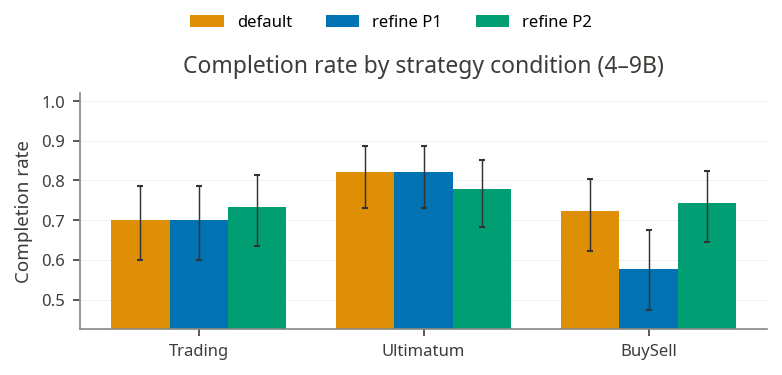

PLOT_DATA[completion_by_condition_very_small]
[{"game":"BuySell","cond":"DD","k":65,"n":90,"rate":0.722222,"lo":0.622048,"hi":0.804203},{"game":"BuySell","cond":"DR","k":67,"n":90,"rate":0.744444,"lo":0.645624,"hi":0.823252},{"game":"BuySell","cond":"RD","k":52,"n":90,"rate":0.577778,"lo":0.474612,"hi":0.674576},{"game":"Trading","cond":"DD","k":63,"n":90,"rate":0.7,"lo":0.598735,"hi":0.784891},{"game":"Trading","cond":"DR","k":66,"n":90,"rate":0.733333,"lo":0.633802,"hi":0.813762},{"game":"Trading","cond":"RD","k":63,"n":90,"rate":0.7,"lo":0.598735,"hi":0.784891},{"game":"Ultimatum","cond":"DD","k":74,"n":90,"rate":0.822222,"lo":0.730561,"hi":0.887503},{"game":"Ultimatum","cond":"DR","k":70,"n":90,"rate":0.777778,"lo":0.681527,"hi":0.851287},{"game":"Ultimatum","cond":"RD","k":74,"n":90,"rate":0.822222,"lo":0.730561,"hi":0.887503}]


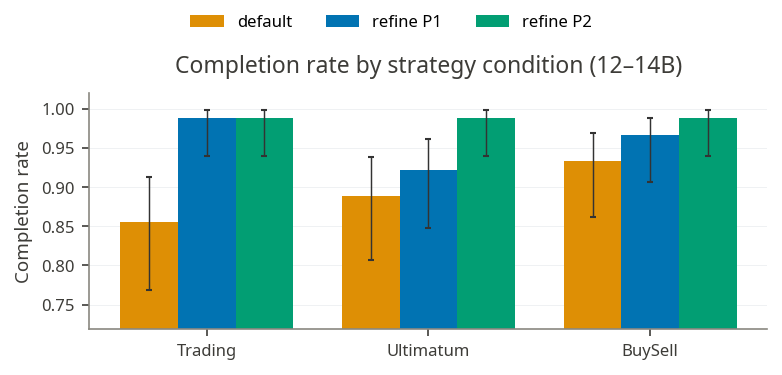

PLOT_DATA[completion_by_condition_small]
[{"game":"BuySell","cond":"DD","k":84,"n":90,"rate":0.933333,"lo":0.862099,"hi":0.96909},{"game":"BuySell","cond":"DR","k":89,"n":90,"rate":0.988889,"lo":0.939716,"hi":0.998036},{"game":"BuySell","cond":"RD","k":87,"n":90,"rate":0.966667,"lo":0.906527,"hi":0.9886},{"game":"Trading","cond":"DD","k":77,"n":90,"rate":0.855556,"lo":0.768401,"hi":0.9136},{"game":"Trading","cond":"DR","k":89,"n":90,"rate":0.988889,"lo":0.939716,"hi":0.998036},{"game":"Trading","cond":"RD","k":89,"n":90,"rate":0.988889,"lo":0.939716,"hi":0.998036},{"game":"Ultimatum","cond":"DD","k":80,"n":90,"rate":0.888889,"lo":0.807422,"hi":0.938517},{"game":"Ultimatum","cond":"DR","k":89,"n":90,"rate":0.988889,"lo":0.939716,"hi":0.998036},{"game":"Ultimatum","cond":"RD","k":83,"n":90,"rate":0.922222,"lo":0.848061,"hi":0.961815}]


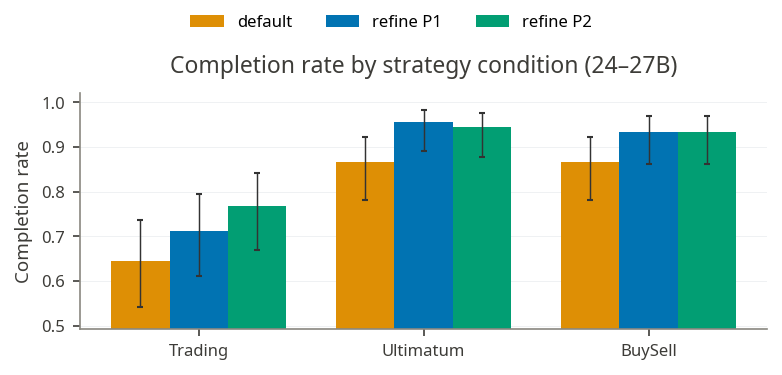

PLOT_DATA[completion_by_condition_medium]
[{"game":"BuySell","cond":"DD","k":78,"n":90,"rate":0.866667,"lo":0.781261,"hi":0.922053},{"game":"BuySell","cond":"DR","k":84,"n":90,"rate":0.933333,"lo":0.862099,"hi":0.96909},{"game":"BuySell","cond":"RD","k":84,"n":90,"rate":0.933333,"lo":0.862099,"hi":0.96909},{"game":"Trading","cond":"DD","k":58,"n":90,"rate":0.644444,"lo":0.541502,"hi":0.735561},{"game":"Trading","cond":"DR","k":69,"n":90,"rate":0.766667,"lo":0.669483,"hi":0.842018},{"game":"Trading","cond":"RD","k":64,"n":90,"rate":0.711111,"lo":0.61036,"hi":0.794579},{"game":"Ultimatum","cond":"DD","k":78,"n":90,"rate":0.866667,"lo":0.781261,"hi":0.922053},{"game":"Ultimatum","cond":"DR","k":85,"n":90,"rate":0.944444,"lo":0.876463,"hi":0.976039},{"game":"Ultimatum","cond":"RD","k":86,"n":90,"rate":0.955556,"lo":0.891231,"hi":0.982583}]


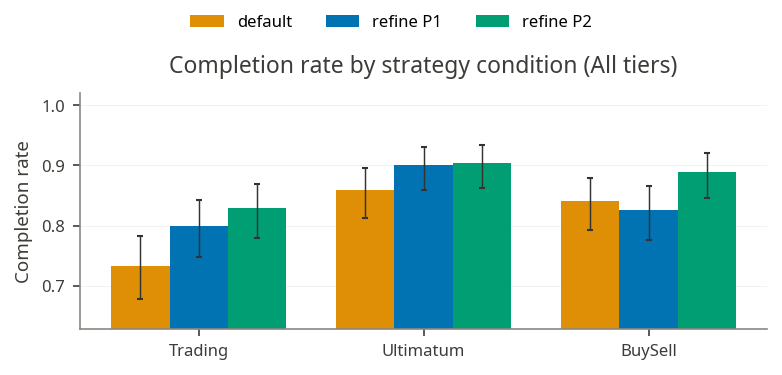

PLOT_DATA[completion_by_condition_all]
[{"game":"BuySell","cond":"DD","k":227,"n":270,"rate":0.840741,"lo":0.792359,"hi":0.879563},{"game":"BuySell","cond":"DR","k":240,"n":270,"rate":0.888889,"lo":0.845814,"hi":0.921053},{"game":"BuySell","cond":"RD","k":223,"n":270,"rate":0.825926,"lo":0.776212,"hi":0.866495},{"game":"Trading","cond":"DD","k":198,"n":270,"rate":0.733333,"lo":0.677582,"hi":0.782538},{"game":"Trading","cond":"DR","k":224,"n":270,"rate":0.82963,"lo":0.780238,"hi":0.869773},{"game":"Trading","cond":"RD","k":216,"n":270,"rate":0.8,"lo":0.748229,"hi":0.843354},{"game":"Ultimatum","cond":"DD","k":232,"n":270,"rate":0.859259,"lo":0.812724,"hi":0.895715},{"game":"Ultimatum","cond":"DR","k":244,"n":270,"rate":0.903704,"lo":0.862645,"hi":0.933436},{"game":"Ultimatum","cond":"RD","k":243,"n":270,"rate":0.9,"lo":0.858416,"hi":0.930361}]


In [73]:
# Per-tier completion facet: completion rate by strategy condition, one figure
# per tier. Mirrors the small-tier notebook's `completion_by_condition`.
def plot_completion(sz):
    comp = COMP[sz]
    if comp is None or comp.empty:
        print(f"[skip] no completion data for {sz}")
        return None
    cc = (comp.groupby(["game", "cond"])
          .agg(k=("completed", "sum"), n=("completed", "count")).reset_index())
    cc = cc[cc["cond"].isin(COND_ORDER)].copy()  # drop RR (excluded from this analysis)
    cc["rate"] = cc["k"] / cc["n"]
    cc[["lo", "hi"]] = cc.apply(lambda r: pd.Series(wilson_ci(r.k, r.n)), axis=1)
    games_present = [g for g in GAME_ORDER if g in set(cc["game"])]
    x = np.arange(len(games_present)); width = 0.26
    fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.85, 2.4))
    for i, c in enumerate(COND_ORDER):
        sub = cc[cc["cond"] == c].set_index("game").reindex(games_present)
        pos = x + (i - (len(COND_ORDER) - 1) / 2) * width
        ax.bar(pos, sub["rate"], width, label=COND_LABEL[c], color=COND_COLORS[c])
        ax.errorbar(pos, sub["rate"],
                    yerr=errbars_from_ci(sub["rate"].values, list(zip(sub["lo"], sub["hi"]))),
                    fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
    ymin = max(0.0, float(cc[["rate", "lo"]].min().min()) - 0.05)
    ax.set_xticks(x, games_present); ax.set_ylabel("Completion rate")
    ax.set_ylim(ymin, 1.02)
    ax.set_title(f"Completion rate by strategy condition ({SIZE_LABEL_EXT[sz]})")
    fig.legend(*ax.get_legend_handles_labels(), loc="outside upper center",
               ncols=3, frameon=False)
    save_plot(fig, f"completion_by_condition_{sz}"); plt.show()
    print_plot_frame(
        f"completion_by_condition_{sz}", cc,
        columns=["game", "cond", "k", "n", "rate", "lo", "hi"],
        sort_by=["game", "cond"],
        round_cols={"rate": 6, "lo": 6, "hi": 6})
    return cc


COMP_BY_TIER = {sz: plot_completion(sz) for sz in PLOT_SIZES}


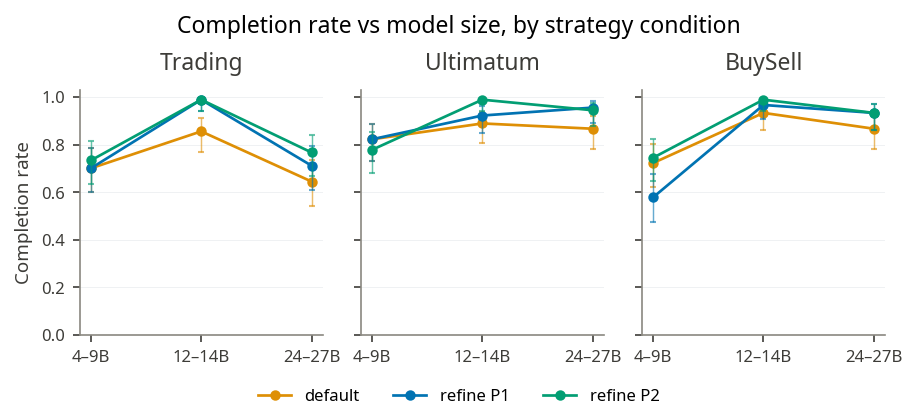

PLOT_DATA[completion_by_tier]
[{"game":"BuySell","cond":"DD","size":"medium","n":90,"rate":0.866667,"lo":0.781261,"hi":0.922053},{"game":"BuySell","cond":"DD","size":"small","n":90,"rate":0.933333,"lo":0.862099,"hi":0.96909},{"game":"BuySell","cond":"DD","size":"very_small","n":90,"rate":0.722222,"lo":0.622048,"hi":0.804203},{"game":"BuySell","cond":"DR","size":"medium","n":90,"rate":0.933333,"lo":0.862099,"hi":0.96909},{"game":"BuySell","cond":"DR","size":"small","n":90,"rate":0.988889,"lo":0.939716,"hi":0.998036},{"game":"BuySell","cond":"DR","size":"very_small","n":90,"rate":0.744444,"lo":0.645624,"hi":0.823252},{"game":"BuySell","cond":"RD","size":"medium","n":90,"rate":0.933333,"lo":0.862099,"hi":0.96909},{"game":"BuySell","cond":"RD","size":"small","n":90,"rate":0.966667,"lo":0.906527,"hi":0.9886},{"game":"BuySell","cond":"RD","size":"very_small","n":90,"rate":0.577778,"lo":0.474612,"hi":0.674576},{"game":"Trading","cond":"DD","size":"medium","n":90,"rate":0.644444,"lo":0.541502,

In [74]:
# Tier trend: completion rate vs model size, one panel per game, one line per
# strategy condition. Reads whether Self-Refine's format lift survives across
# scale.
trend_rows = []
fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.7), sharey=True)
xs = np.arange(len(SIZES))
for ax, g in zip(axes, GAME_ORDER):
    for c in COND_ORDER:
        ys, los, his = [], [], []
        for sz in SIZES:
            cc = COMP_BY_TIER.get(sz)
            if cc is None:
                ys.append(np.nan); los.append(np.nan); his.append(np.nan); continue
            row = cc[(cc["game"] == g) & (cc["cond"] == c)]
            if len(row):
                r = row.iloc[0]
                ys.append(r["rate"]); los.append(r["lo"]); his.append(r["hi"])
                trend_rows.append(dict(game=g, cond=c, size=sz, rate=r["rate"],
                                       lo=r["lo"], hi=r["hi"], n=int(r["n"])))
            else:
                ys.append(np.nan); los.append(np.nan); his.append(np.nan)
        ys = np.array(ys, float)
        ax.plot(xs, ys, marker="o", ms=4, lw=1.3, color=COND_COLORS[c],
                label=COND_LABEL[c])
        ax.errorbar(xs, ys, yerr=errbars_from_ci(ys, list(zip(los, his))),
                    fmt="none", ecolor=COND_COLORS[c], lw=0.7, capsize=1.5, alpha=0.6)
    ax.set_xticks(xs, [SIZE_LABEL[s] for s in SIZES])
    ax.set_title(g); ax.set_ylim(0, 1.03)
axes[0].set_ylabel("Completion rate")
fig.suptitle("Completion rate vs model size, by strategy condition")
# de-duplicate the legend (RD and DR share a color/label group)
h, l = axes[0].get_legend_handles_labels()
seen = dict(zip(l, h))
fig.legend(seen.values(), seen.keys(), loc="outside lower center", ncols=3, frameon=False)
save_plot(fig, "completion_by_tier"); plt.show()

print_plot_frame(
    "completion_by_tier", pd.DataFrame(trend_rows),
    columns=["game", "cond", "size", "k" if False else "n", "rate", "lo", "hi"],
    sort_by=["game", "cond", "size"],
    round_cols={"rate": 6, "lo": 6, "hi": 6})


Self-Refine's format critique mostly *raises* completion: pooled across tiers, a refined seat reaches a valid terminal state at least as often as `DD` in every game (DR vs DD: BuySell .889 vs .841, Trading .830 vs .733, Ultimatum .904 vs .859). The lift is cleanest at the small tier (Trading DD .856 → DR/RD .989; Ultimatum .889 → .989). At the very-small tier it is noisy and can backfire: BuySell RD drops to .58 against a .72 DD baseline. Completion is not monotone in size, with medium Trading DD dipping to .64. Refinement helps format compliance, but reliably only once models are large enough to act on the critique.


## 2. Refining impact on winrate and payoff

Each seat is compared against its own seat-matched `DD` baseline:

- **refine P1** is Player 1 in `RD` versus Player 1 in `DD`,
- **refine P2** is Player 2 in `DR` versus Player 2 in `DD`.


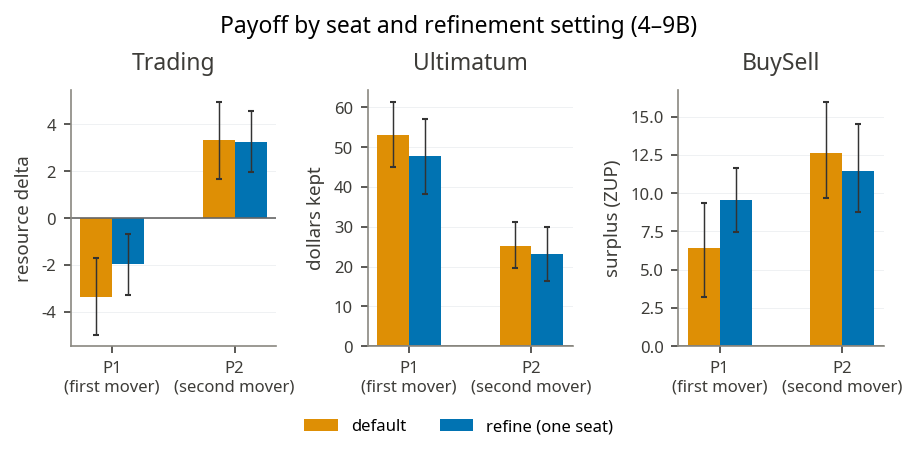

PLOT_DATA[refine_effect_by_seat_very_small]
[{"game":"BuySell","seat":1,"setting":"default","n":65,"mean":6.446154,"lo":3.215385,"hi":9.323077},{"game":"BuySell","seat":1,"setting":"refine","n":52,"mean":9.538462,"lo":7.480769,"hi":11.634615},{"game":"BuySell","seat":2,"setting":"default","n":65,"mean":12.630769,"lo":9.676923,"hi":15.938462},{"game":"BuySell","seat":2,"setting":"refine","n":67,"mean":11.462687,"lo":8.776119,"hi":14.477985},{"game":"Trading","seat":1,"setting":"default","n":63,"mean":-3.349206,"lo":-4.968651,"hi":-1.68254},{"game":"Trading","seat":1,"setting":"refine","n":63,"mean":-1.936508,"lo":-3.285714,"hi":-0.666667},{"game":"Trading","seat":2,"setting":"default","n":63,"mean":3.349206,"lo":1.68254,"hi":4.968651},{"game":"Trading","seat":2,"setting":"refine","n":66,"mean":3.257576,"lo":1.969318,"hi":4.576136},{"game":"Ultimatum","seat":1,"setting":"default","n":74,"mean":53.148649,"lo":45.10777,"hi":61.297297},{"game":"Ultimatum","seat":1,"setting":"refine","n":74,

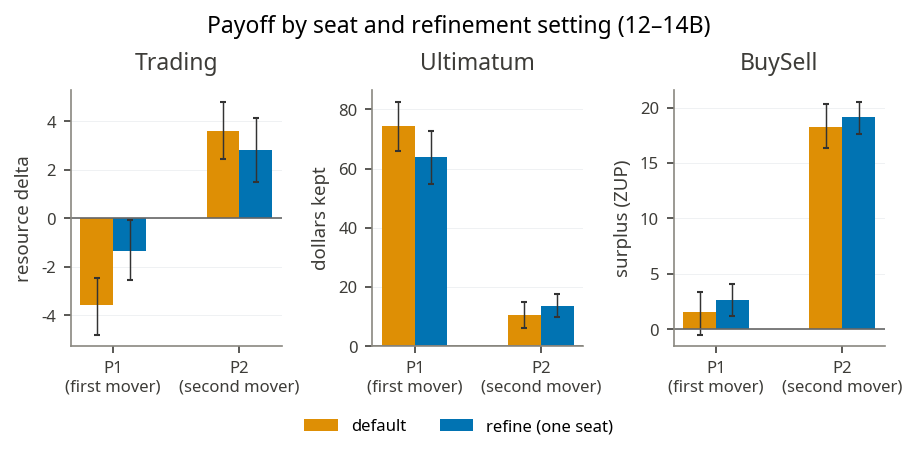

PLOT_DATA[refine_effect_by_seat_small]
[{"game":"BuySell","seat":1,"setting":"default","n":84,"mean":1.547619,"lo":-0.464286,"hi":3.416667},{"game":"BuySell","seat":1,"setting":"refine","n":87,"mean":2.678161,"lo":1.229885,"hi":4.103448},{"game":"BuySell","seat":2,"setting":"default","n":84,"mean":18.214286,"lo":16.309226,"hi":20.285714},{"game":"BuySell","seat":2,"setting":"refine","n":88,"mean":19.102273,"lo":17.625,"hi":20.534375},{"game":"Trading","seat":1,"setting":"default","n":77,"mean":-3.571429,"lo":-4.805195,"hi":-2.454545},{"game":"Trading","seat":1,"setting":"refine","n":89,"mean":-1.337079,"lo":-2.573034,"hi":-0.089888},{"game":"Trading","seat":2,"setting":"default","n":77,"mean":3.571429,"lo":2.454545,"hi":4.805195},{"game":"Trading","seat":2,"setting":"refine","n":89,"mean":2.820225,"lo":1.483146,"hi":4.146348},{"game":"Ultimatum","seat":1,"setting":"default","n":80,"mean":74.5,"lo":66.074688,"hi":82.45},{"game":"Ultimatum","seat":1,"setting":"refine","n":83,"mean":63.90

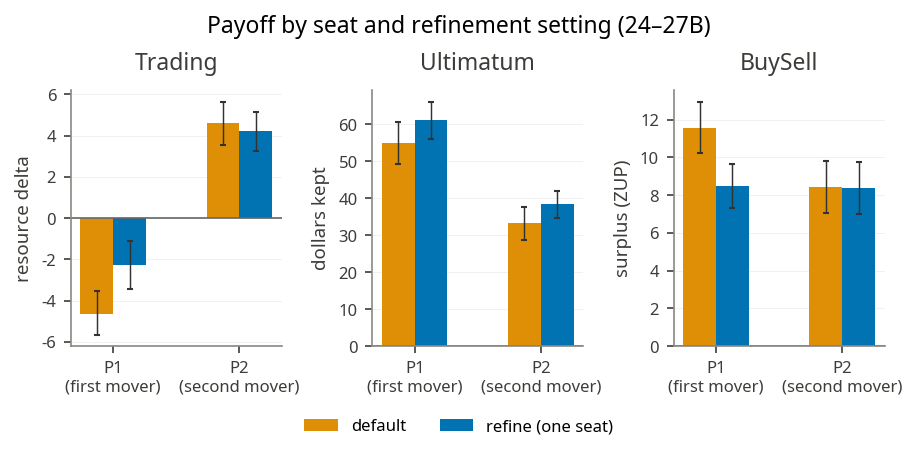

PLOT_DATA[refine_effect_by_seat_medium]
[{"game":"BuySell","seat":1,"setting":"default","n":78,"mean":11.564103,"lo":10.205128,"hi":12.923077},{"game":"BuySell","seat":1,"setting":"refine","n":84,"mean":8.5,"lo":7.297619,"hi":9.666667},{"game":"BuySell","seat":2,"setting":"default","n":78,"mean":8.435897,"lo":7.076923,"hi":9.794872},{"game":"BuySell","seat":2,"setting":"refine","n":84,"mean":8.369048,"lo":6.999702,"hi":9.75},{"game":"Trading","seat":1,"setting":"default","n":58,"mean":-4.637931,"lo":-5.655172,"hi":-3.534483},{"game":"Trading","seat":1,"setting":"refine","n":64,"mean":-2.265625,"lo":-3.421875,"hi":-1.09375},{"game":"Trading","seat":2,"setting":"default","n":58,"mean":4.637931,"lo":3.534483,"hi":5.655172},{"game":"Trading","seat":2,"setting":"refine","n":69,"mean":4.202899,"lo":3.275362,"hi":5.130435},{"game":"Ultimatum","seat":1,"setting":"default","n":78,"mean":55.051282,"lo":49.141026,"hi":60.551603},{"game":"Ultimatum","seat":1,"setting":"refine","n":86,"mean":61.267

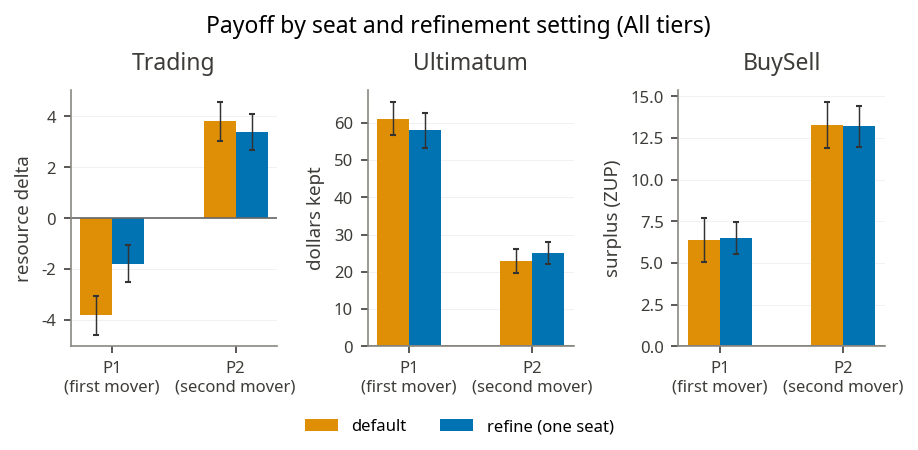

PLOT_DATA[refine_effect_by_seat_all]
[{"game":"BuySell","seat":1,"setting":"default","n":227,"mean":6.39207,"lo":5.035132,"hi":7.713656},{"game":"BuySell","seat":1,"setting":"refine","n":223,"mean":6.470852,"lo":5.529148,"hi":7.430605},{"game":"BuySell","seat":2,"setting":"default","n":227,"mean":13.255507,"lo":11.916189,"hi":14.647577},{"game":"BuySell","seat":2,"setting":"refine","n":239,"mean":13.188285,"lo":11.974895,"hi":14.435251},{"game":"Trading","seat":1,"setting":"default","n":198,"mean":-3.813131,"lo":-4.580808,"hi":-3.045455},{"game":"Trading","seat":1,"setting":"refine","n":216,"mean":-1.787037,"lo":-2.513889,"hi":-1.046296},{"game":"Trading","seat":2,"setting":"default","n":198,"mean":3.813131,"lo":3.045455,"hi":4.580808},{"game":"Trading","seat":2,"setting":"refine","n":224,"mean":3.375,"lo":2.665179,"hi":4.09375},{"game":"Ultimatum","seat":1,"setting":"default","n":232,"mean":61.150862,"lo":56.836207,"hi":65.560453},{"game":"Ultimatum","seat":1,"setting":"refine","n":24

In [75]:
# Seat-resolved comparisons reused by both the facet figures and the trend
# figures below. Every comparison is against the seat-matched DD baseline.
SEAT_SETTING = ["default", "refine"]
_SEAT_COND = {(1, "default"): "DD", (1, "refine"): "RD",
              (2, "default"): "DD", (2, "refine"): "DR"}


def seat_payoff(df, seat, setting):
    if not len(df):
        return np.array([], float)
    col = "payoff_1" if seat == 1 else "payoff_2"
    return df[df["cond"] == _SEAT_COND[(seat, setting)]][col].values.astype(float)


def seat_winrate(df, seat, setting):
    if not len(df):
        return np.nan, 0, 0
    sub = df[df["cond"] == _SEAT_COND[(seat, setting)]]
    if seat == 1:
        w, l = int(sub["win_1"].sum()), int(sub["win_2"].sum())
    else:
        w, l = int(sub["win_2"].sum()), int(sub["win_1"].sum())
    return win_rate(w, l)


def _diff_ci(ref, base, n=4000, seed=0):
    ref, base = np.asarray(ref, float), np.asarray(base, float)
    if not len(ref) or not len(base):
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    d = [rng.choice(ref, ref.size).mean() - rng.choice(base, base.size).mean()
         for _ in range(n)]
    return float(np.percentile(d, 2.5)), float(np.percentile(d, 97.5))


# Per-tier facet: one panel per game, two seat groups (P1, P2), each with
# default / refine-this-seat bars carrying bootstrap CIs.
def plot_seat_payoff(sz):
    out = OUT[sz]
    games_present = [g for g in GAME_ORDER if len(out[g])]
    if not games_present:
        print(f"[skip] no payoff data for {sz}")
        return None
    seat_plot = []
    fig, axes = plt.subplots(1, len(games_present), figsize=(FULL_WIDTH, 2.9),
                             squeeze=False)
    axes = axes[0]
    group_x = np.arange(2); width = 0.26
    for ax, g in zip(axes, games_present):
        df = out[g]
        for i, s in enumerate(SEAT_SETTING):
            centers, los, his = [], [], []
            for seat in (1, 2):
                vals = seat_payoff(df, seat, s)
                center = np.mean(vals) if len(vals) else np.nan
                lo, hi = bootstrap_ci(vals)
                centers.append(center); los.append(lo); his.append(hi)
                seat_plot.append(dict(size=sz, game=g, seat=seat, setting=s,
                                      n=len(vals), mean=center, lo=lo, hi=hi))
            pos = group_x + (i - (len(SEAT_SETTING) - 1) / 2) * width
            ax.bar(pos, centers, width, label=SETTING_LABEL[s], color=SETTING_COLORS[s])
            ax.errorbar(pos, centers,
                        yerr=errbars_from_ci(np.array(centers, float), list(zip(los, his))),
                        fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
        ax.axhline(0, lw=0.8, color="0.4")
        ax.set_xticks(group_x, ["P1\n(first mover)", "P2\n(second mover)"])
        ax.set_title(g); ax.set_ylabel(GAME_NATIVE_UNIT[g])
    fig.suptitle(f"Payoff by seat and refinement setting ({SIZE_LABEL_EXT[sz]})")
    fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center",
               ncols=2, frameon=False)
    save_plot(fig, f"refine_effect_by_seat_{sz}"); plt.show()
    print_plot_frame(
        f"refine_effect_by_seat_{sz}", pd.DataFrame(seat_plot),
        columns=["game", "seat", "setting", "n", "mean", "lo", "hi"],
        sort_by=["game", "seat", "setting"],
        round_cols={"mean": 6, "lo": 6, "hi": 6})
    return pd.DataFrame(seat_plot)


for sz in PLOT_SIZES:
    plot_seat_payoff(sz)


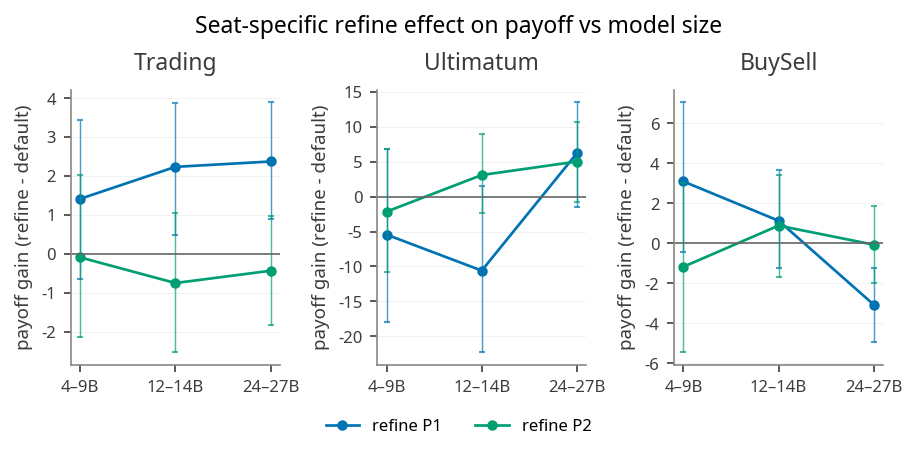

PLOT_DATA[refine_payoff_effect_by_tier]
[{"game":"BuySell","seat":"P1","size":"medium","n":84,"delta":-3.064103,"lo":-4.929853,"hi":-1.243475},{"game":"BuySell","seat":"P1","size":"small","n":87,"delta":1.130542,"lo":-1.247137,"hi":3.663773},{"game":"BuySell","seat":"P1","size":"very_small","n":52,"delta":3.092308,"lo":-0.454519,"hi":7.042404},{"game":"BuySell","seat":"P2","size":"medium","n":84,"delta":-0.06685,"lo":-1.964354,"hi":1.890293},{"game":"BuySell","seat":"P2","size":"small","n":88,"delta":0.887987,"lo":-1.689976,"hi":3.394048},{"game":"BuySell","seat":"P2","size":"very_small","n":67,"delta":-1.168083,"lo":-5.435752,"hi":2.998375},{"game":"Trading","seat":"P1","size":"medium","n":64,"delta":2.372306,"lo":0.883621,"hi":3.890746},{"game":"Trading","seat":"P1","size":"small","n":89,"delta":2.23435,"lo":0.471735,"hi":3.881796},{"game":"Trading","seat":"P1","size":"very_small","n":63,"delta":1.412698,"lo":-0.650794,"hi":3.428571},{"game":"Trading","seat":"P2","size":"medium","n":

In [76]:
# Tier trend: seat-specific refine effect (refine that seat - its own DD
# baseline, native payoff units) vs model size, one panel per game, one line per
# seat, with a bootstrap CI on the difference.
SEAT_EFFECT_COLORS = {1: "#0173b2", 2: "#029e73"}
eff_rows = []
fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.9))
xs = np.arange(len(SIZES))
for ax, g in zip(axes, GAME_ORDER):
    for seat in (1, 2):
        ys, los, his = [], [], []
        for k, sz in enumerate(SIZES):
            df = OUT[sz][g]
            base = seat_payoff(df, seat, "default")
            ref = seat_payoff(df, seat, "refine")
            if len(base) and len(ref):
                d = ref.mean() - base.mean()
                lo, hi = _diff_ci(ref, base, seed=7 + seat + 3 * k)
            else:
                d, lo, hi = np.nan, np.nan, np.nan
            ys.append(d); los.append(lo); his.append(hi)
            eff_rows.append(dict(game=g, seat=f"P{seat}", size=sz, delta=d,
                                 lo=lo, hi=hi, n=len(ref)))
        ys = np.array(ys, float)
        ax.plot(xs, ys, marker="o", ms=4, lw=1.3, color=SEAT_EFFECT_COLORS[seat],
                label=f"refine P{seat}")
        ax.errorbar(xs, ys, yerr=errbars_from_ci(ys, list(zip(los, his))),
                    fmt="none", ecolor=SEAT_EFFECT_COLORS[seat], lw=0.7,
                    capsize=1.5, alpha=0.7)
    ax.axhline(0, lw=0.8, color="0.4")
    ax.set_xticks(xs, [SIZE_LABEL[s] for s in SIZES])
    ax.set_title(g); ax.set_ylabel("payoff gain (refine - default)")
fig.suptitle("Seat-specific refine effect on payoff vs model size")
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center",
           ncols=2, frameon=False)
save_plot(fig, "refine_payoff_effect_by_tier"); plt.show()

print_plot_frame(
    "refine_payoff_effect_by_tier", pd.DataFrame(eff_rows),
    columns=["game", "seat", "size", "n", "delta", "lo", "hi"],
    sort_by=["game", "seat", "size"],
    round_cols={"delta": 6, "lo": 6, "hi": 6})


Only one cell shows a consistent, CI-backed payoff gain: Trading P1, the structurally weak first-mover, rises at every tier (+1.4 / +2.2 / +2.4 native units; CI excludes 0 at small and medium). Elsewhere the seat-specific effect is small and statistically indistinguishable from zero, with two caveats: medium BuySell P1 *loses* surplus (−3.1, CI excl. 0) because that seller was already strong, and Ultimatum effects are swamped by very wide bootstrap CIs. Refinement does not broadly raise payoff — it mainly compensates a disadvantaged proposer.

### Win rate by seat

The same seat-resolved comparison read as win rate (ties excluded). The 0.5 line
is parity: a seat neither helped nor hurt relative to a default opponent. The
trend figure tracks the win-rate shift from refining a seat (refine-this-seat
minus the seat-matched `DD` win rate) across model size.


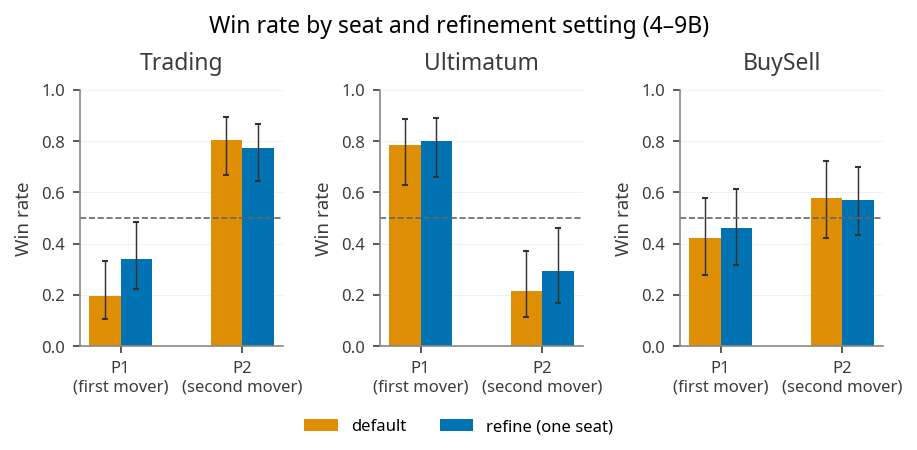

PLOT_DATA[winrate_refine_effect_by_seat_very_small]
[{"game":"BuySell","seat":1,"setting":"default","k":16,"n":38,"rate":0.421053,"lo":0.278525,"hi":0.578077},{"game":"BuySell","seat":1,"setting":"refine","k":18,"n":39,"rate":0.461538,"lo":0.315669,"hi":0.614306},{"game":"BuySell","seat":2,"setting":"default","k":22,"n":38,"rate":0.578947,"lo":0.421923,"hi":0.721475},{"game":"BuySell","seat":2,"setting":"refine","k":28,"n":49,"rate":0.571429,"lo":0.432705,"hi":0.699767},{"game":"Trading","seat":1,"setting":"default","k":9,"n":46,"rate":0.195652,"lo":0.106506,"hi":0.331713},{"game":"Trading","seat":1,"setting":"refine","k":16,"n":47,"rate":0.340426,"lo":0.221674,"hi":0.483291},{"game":"Trading","seat":2,"setting":"default","k":37,"n":46,"rate":0.804348,"lo":0.668287,"hi":0.893494},{"game":"Trading","seat":2,"setting":"refine","k":41,"n":53,"rate":0.773585,"lo":0.644737,"hi":0.865454},{"game":"Ultimatum","seat":1,"setting":"default","k":29,"n":37,"rate":0.783784,"lo":0.628049,"hi":0.8861

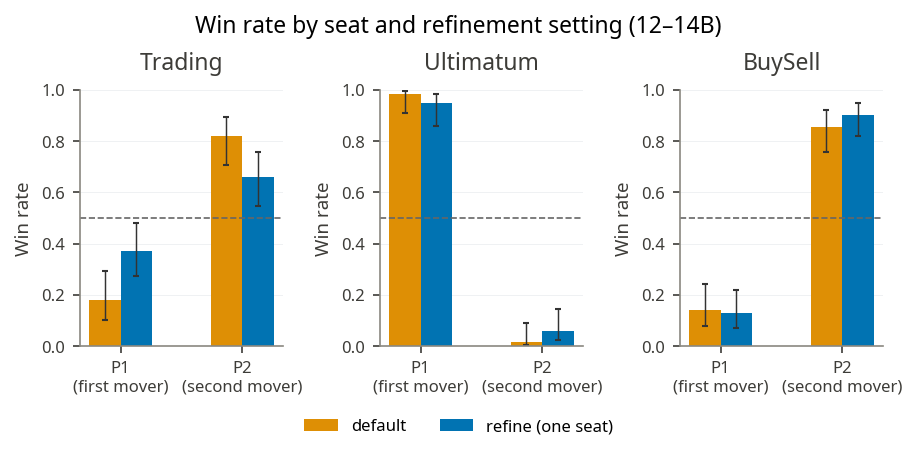

PLOT_DATA[winrate_refine_effect_by_seat_small]
[{"game":"BuySell","seat":1,"setting":"default","k":10,"n":70,"rate":0.142857,"lo":0.079489,"hi":0.243384},{"game":"BuySell","seat":1,"setting":"refine","k":10,"n":78,"rate":0.128205,"lo":0.071153,"hi":0.22016},{"game":"BuySell","seat":2,"setting":"default","k":60,"n":70,"rate":0.857143,"lo":0.756616,"hi":0.920511},{"game":"BuySell","seat":2,"setting":"refine","k":74,"n":82,"rate":0.902439,"lo":0.819128,"hi":0.949731},{"game":"Trading","seat":1,"setting":"default","k":11,"n":61,"rate":0.180328,"lo":0.103791,"hi":0.294742},{"game":"Trading","seat":1,"setting":"refine","k":30,"n":81,"rate":0.37037,"lo":0.273317,"hi":0.479163},{"game":"Trading","seat":2,"setting":"default","k":50,"n":61,"rate":0.819672,"lo":0.705258,"hi":0.896209},{"game":"Trading","seat":2,"setting":"refine","k":49,"n":74,"rate":0.662162,"lo":0.548785,"hi":0.759534},{"game":"Ultimatum","seat":1,"setting":"default","k":58,"n":59,"rate":0.983051,"lo":0.910043,"hi":0.997002},{"

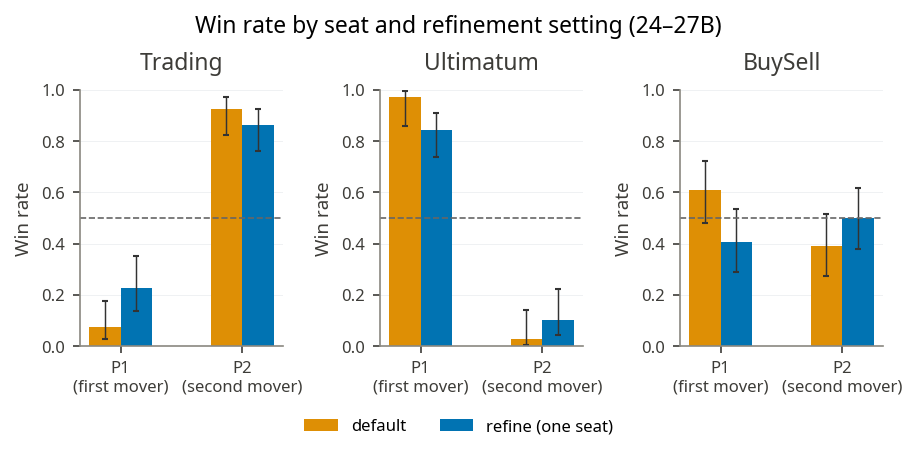

PLOT_DATA[winrate_refine_effect_by_seat_medium]
[{"game":"BuySell","seat":1,"setting":"default","k":36,"n":59,"rate":0.610169,"lo":0.482663,"hi":0.724206},{"game":"BuySell","seat":1,"setting":"refine","k":24,"n":59,"rate":0.40678,"lo":0.29089,"hi":0.534066},{"game":"BuySell","seat":2,"setting":"default","k":23,"n":59,"rate":0.389831,"lo":0.275794,"hi":0.517337},{"game":"BuySell","seat":2,"setting":"refine","k":32,"n":64,"rate":0.5,"lo":0.381021,"hi":0.618979},{"game":"Trading","seat":1,"setting":"default","k":4,"n":54,"rate":0.074074,"lo":0.029182,"hi":0.175541},{"game":"Trading","seat":1,"setting":"refine","k":13,"n":57,"rate":0.22807,"lo":0.138419,"hi":0.35206},{"game":"Trading","seat":2,"setting":"default","k":50,"n":54,"rate":0.925926,"lo":0.824459,"hi":0.970818},{"game":"Trading","seat":2,"setting":"refine","k":57,"n":66,"rate":0.863636,"lo":0.760704,"hi":0.926567},{"game":"Ultimatum","seat":1,"setting":"default","k":35,"n":36,"rate":0.972222,"lo":0.858303,"hi":0.99508},{"game":"U

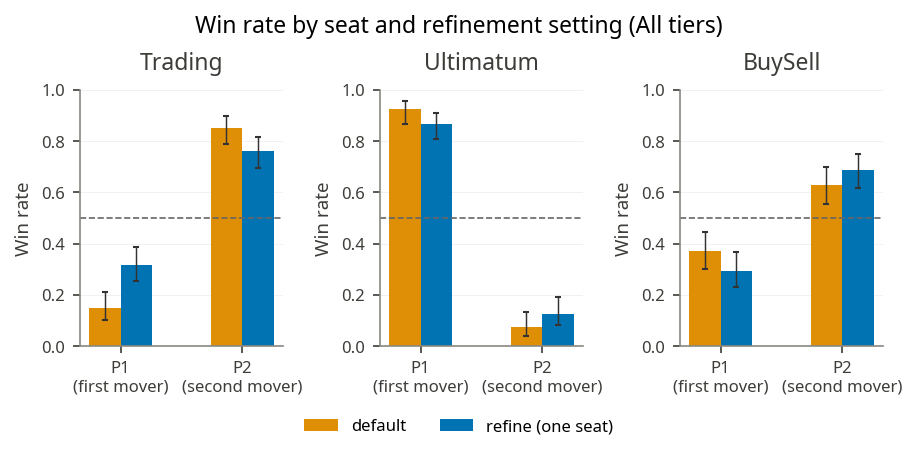

PLOT_DATA[winrate_refine_effect_by_seat_all]
[{"game":"BuySell","seat":1,"setting":"default","k":62,"n":167,"rate":0.371257,"lo":0.301647,"hi":0.446658},{"game":"BuySell","seat":1,"setting":"refine","k":52,"n":176,"rate":0.295455,"lo":0.233,"hi":0.366648},{"game":"BuySell","seat":2,"setting":"default","k":105,"n":167,"rate":0.628743,"lo":0.553342,"hi":0.698353},{"game":"BuySell","seat":2,"setting":"refine","k":134,"n":195,"rate":0.687179,"lo":0.619019,"hi":0.748108},{"game":"Trading","seat":1,"setting":"default","k":24,"n":161,"rate":0.149068,"lo":0.102265,"hi":0.212227},{"game":"Trading","seat":1,"setting":"refine","k":59,"n":185,"rate":0.318919,"lo":0.256028,"hi":0.389177},{"game":"Trading","seat":2,"setting":"default","k":137,"n":161,"rate":0.850932,"lo":0.787773,"hi":0.897735},{"game":"Trading","seat":2,"setting":"refine","k":147,"n":193,"rate":0.761658,"lo":0.696812,"hi":0.816291},{"game":"Ultimatum","seat":1,"setting":"default","k":122,"n":132,"rate":0.924242,"lo":0.866159,"hi":0

In [77]:
# Per-tier facet: seat-resolved win rate (ties excluded) under default / refine
# this seat, one panel per game.
def plot_seat_winrate(sz):
    out = OUT[sz]
    games_present = [g for g in GAME_ORDER if len(out[g])]
    if not games_present:
        print(f"[skip] no win-rate data for {sz}")
        return None
    seat_wr = []
    fig, axes = plt.subplots(1, len(games_present), figsize=(FULL_WIDTH, 2.9),
                             squeeze=False)
    axes = axes[0]
    group_x = np.arange(2); width = 0.26
    for ax, g in zip(axes, games_present):
        df = out[g]
        for i, s in enumerate(SEAT_SETTING):
            rates, los, his = [], [], []
            for seat in (1, 2):
                rate, k, n = seat_winrate(df, seat, s)
                lo, hi = wilson_ci(k, n)
                rates.append(rate); los.append(lo); his.append(hi)
                seat_wr.append(dict(size=sz, game=g, seat=seat, setting=s,
                                    rate=rate, k=k, n=n, lo=lo, hi=hi))
            pos = group_x + (i - (len(SEAT_SETTING) - 1) / 2) * width
            ax.bar(pos, rates, width, label=SETTING_LABEL[s], color=SETTING_COLORS[s])
            ax.errorbar(pos, rates,
                        yerr=errbars_from_ci(np.array(rates, float), list(zip(los, his))),
                        fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
        ax.axhline(0.5, ls="--", lw=0.8, color="0.4")
        ax.set_xticks(group_x, ["P1\n(first mover)", "P2\n(second mover)"])
        ax.set_title(g); ax.set_ylabel("Win rate"); ax.set_ylim(0, 1.0)
    fig.suptitle(f"Win rate by seat and refinement setting ({SIZE_LABEL_EXT[sz]})")
    fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center",
               ncols=2, frameon=False)
    save_plot(fig, f"winrate_refine_effect_by_seat_{sz}"); plt.show()
    print_plot_frame(
        f"winrate_refine_effect_by_seat_{sz}", pd.DataFrame(seat_wr),
        columns=["game", "seat", "setting", "k", "n", "rate", "lo", "hi"],
        sort_by=["game", "seat", "setting"],
        round_cols={"rate": 6, "lo": 6, "hi": 6})
    return pd.DataFrame(seat_wr)


for sz in PLOT_SIZES:
    plot_seat_winrate(sz)


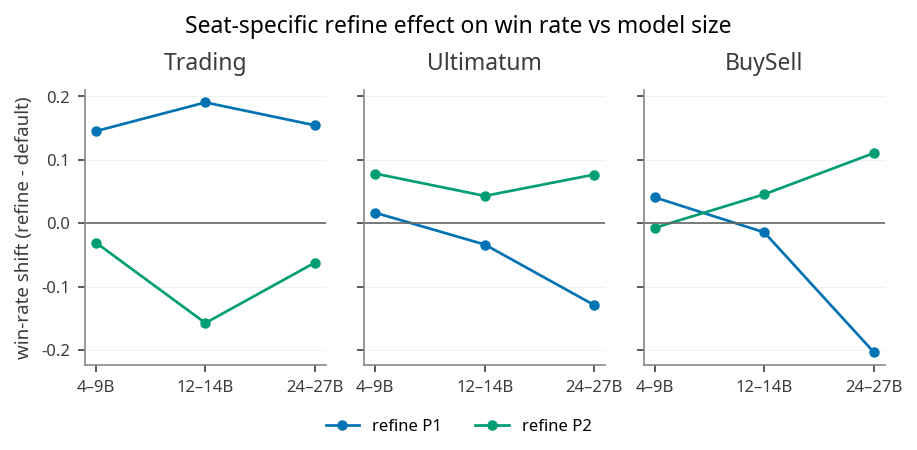

PLOT_DATA[refine_winrate_effect_by_tier]
[{"game":"BuySell","seat":"P1","size":"medium","default_wr":0.610169,"refine_wr":0.40678,"delta":-0.20339},{"game":"BuySell","seat":"P1","size":"small","default_wr":0.142857,"refine_wr":0.128205,"delta":-0.014652},{"game":"BuySell","seat":"P1","size":"very_small","default_wr":0.421053,"refine_wr":0.461538,"delta":0.040486},{"game":"BuySell","seat":"P2","size":"medium","default_wr":0.389831,"refine_wr":0.5,"delta":0.110169},{"game":"BuySell","seat":"P2","size":"small","default_wr":0.857143,"refine_wr":0.902439,"delta":0.045296},{"game":"BuySell","seat":"P2","size":"very_small","default_wr":0.578947,"refine_wr":0.571429,"delta":-0.007519},{"game":"Trading","seat":"P1","size":"medium","default_wr":0.074074,"refine_wr":0.22807,"delta":0.153996},{"game":"Trading","seat":"P1","size":"small","default_wr":0.180328,"refine_wr":0.37037,"delta":0.190043},{"game":"Trading","seat":"P1","size":"very_small","default_wr":0.195652,"refine_wr":0.340426,"delta":0.

In [78]:
# Tier trend: win-rate shift from refining a seat (refine-this-seat win rate
# minus the seat-matched DD win rate) vs model size, one panel per game, one
# line per seat.
wr_rows = []
fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.9), sharey=True)
xs = np.arange(len(SIZES))
for ax, g in zip(axes, GAME_ORDER):
    for seat in (1, 2):
        ys = []
        for sz in SIZES:
            df = OUT[sz][g]
            base, _, bn = seat_winrate(df, seat, "default")
            ref, _, rn = seat_winrate(df, seat, "refine")
            d = (ref - base) if (bn and rn) else np.nan
            ys.append(d)
            wr_rows.append(dict(game=g, seat=f"P{seat}", size=sz,
                                default_wr=base, refine_wr=ref, delta=d))
        ax.plot(xs, np.array(ys, float), marker="o", ms=4, lw=1.3,
                color=SEAT_EFFECT_COLORS[seat], label=f"refine P{seat}")
    ax.axhline(0, lw=0.8, color="0.4")
    ax.set_xticks(xs, [SIZE_LABEL[s] for s in SIZES])
    ax.set_title(g)
axes[0].set_ylabel("win-rate shift (refine - default)")
fig.suptitle("Seat-specific refine effect on win rate vs model size")
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center",
           ncols=2, frameon=False)
save_plot(fig, "refine_winrate_effect_by_tier"); plt.show()

print_plot_frame(
    "refine_winrate_effect_by_tier", pd.DataFrame(wr_rows),
    columns=["game", "seat", "size", "default_wr", "refine_wr", "delta"],
    sort_by=["game", "seat", "size"],
    round_cols={"default_wr": 6, "refine_wr": 6, "delta": 6})


Win rate mirrors payoff. Refining the structurally weak seat lifts it (Trading P1 +14–19 pp at all three tiers; Ultimatum P2 +4–8 pp), while refining the already-strong seat tends to *cost* win rate (Trading P2 −3 to −16 pp; Ultimatum P1 −3 to −13 pp). BuySell is mixed and tier-dependent (P1 +4 pp very-small → −20 pp medium). The pattern is compression of the role gap, not a uniform lift.

### Disadvantaged seats

 This block asks whether
Self-Refine is especially useful when it is assigned to the structurally weak
seat. 

In [79]:
# Disadvantaged-seat summary: refine-this-seat minus the seat-matched DD baseline.
# A seat is disadvantaged by its benchmark role: P1 in Trading and BuySell,
# P2 in Ultimatum.
STRUCTURAL_DISADVANTAGED = {("Trading", "P1"), ("Ultimatum", "P2"), ("BuySell", "P1")}


def _winprob_vec(df, seat, setting):
    """Ties-excluded 1/0 win vector for a seat under a setting."""
    sub = df[df["cond"] == _SEAT_COND[(seat, setting)]]
    decisive = sub[(sub["win_1"] == 1) | (sub["win_2"] == 1)]
    col = "win_1" if seat == 1 else "win_2"
    return decisive[col].values.astype(float)


def _seat_summary_rows():
    rows = []
    for sz in SIZES:
        for g in GAME_ORDER:
            df = OUT[sz][g]
            if df is None or not len(df):
                continue
            for seat in (1, 2):
                seat_label = f"P{seat}"
                base_wr, base_w, base_n = seat_winrate(df, seat, "default")
                ref_wr, ref_w, ref_n = seat_winrate(df, seat, "refine")
                base_pay = seat_payoff(df, seat, "default")
                ref_pay = seat_payoff(df, seat, "refine")
                pay_lo, pay_hi = _diff_ci(ref_pay, base_pay, seed=101 + 17 * SIZES.index(sz) + seat)
                wr_lo, wr_hi = _diff_ci(
                    _winprob_vec(df, seat, "refine"),
                    _winprob_vec(df, seat, "default"),
                    seed=151 + 19 * SIZES.index(sz) + seat,
                )
                rows.append(dict(
                    size=sz, size_label=SIZE_LABEL[sz], game=g, seat=seat_label,
                    structural_disadvantaged=(g, seat_label) in STRUCTURAL_DISADVANTAGED,
                    default_wr=base_wr, refine_wr=ref_wr,
                    wr_delta=ref_wr - base_wr if base_n and ref_n else np.nan,
                    wr_lo=wr_lo, wr_hi=wr_hi,
                    wr_ci_excl0=bool((not np.isnan(wr_lo)) and (wr_lo > 0 or wr_hi < 0)),
                    default_wins=f"{base_w}/{base_n}", refine_wins=f"{ref_w}/{ref_n}",
                    default_pay=float(np.mean(base_pay)) if len(base_pay) else np.nan,
                    refine_pay=float(np.mean(ref_pay)) if len(ref_pay) else np.nan,
                    pay_delta=float(np.mean(ref_pay) - np.mean(base_pay)) if len(base_pay) and len(ref_pay) else np.nan,
                    pay_lo=pay_lo, pay_hi=pay_hi,
                    pay_ci_excl0=bool((not np.isnan(pay_lo)) and (pay_lo > 0 or pay_hi < 0)),
                    n_default=len(base_pay), n_refine=len(ref_pay),
                ))
    return pd.DataFrame(rows)


DISADV_SUMMARY = _seat_summary_rows()

# Compact table for the main result: structural weak seats only.
main_disadv = DISADV_SUMMARY[DISADV_SUMMARY["structural_disadvantaged"]].copy()
main_disadv["wr_delta_pp"] = 100 * main_disadv["wr_delta"]
main_disadv["payoff_delta"] = main_disadv["pay_delta"]

print_plot_frame(
    "self_refine_structural_disadvantaged_seats", main_disadv,
    columns=["game", "seat", "size", "default_wr", "refine_wr", "wr_delta_pp",
             "wr_ci_excl0", "default_pay", "refine_pay", "payoff_delta", "pay_ci_excl0",
             "n_default", "n_refine"],
    sort_by=["game", "seat", "size"],
    round_cols={"default_wr": 4, "refine_wr": 4, "wr_delta_pp": 2,
                "default_pay": 3, "refine_pay": 3, "payoff_delta": 3})

# Thesis-facing aggregate: does refine help weak seats more often than strong seats?
agg_rows = []
for label_col in ["structural_disadvantaged"]:
    for value, sub in DISADV_SUMMARY.groupby(label_col):
        agg_rows.append(dict(
            disadvantage_definition=label_col.replace("_", " "),
            disadvantaged=bool(value),
            n_cells=len(sub),
            wr_delta_mean=sub["wr_delta"].mean(),
            wr_delta_median=sub["wr_delta"].median(),
            wr_delta_positive=int((sub["wr_delta"] > 0).sum()),
            wr_delta_negative=int((sub["wr_delta"] < 0).sum()),
            pay_delta_mean=sub["pay_delta"].mean(),
            pay_delta_median=sub["pay_delta"].median(),
            pay_delta_positive=int((sub["pay_delta"] > 0).sum()),
            pay_delta_negative=int((sub["pay_delta"] < 0).sum()),
        ))
DISADV_AGG = pd.DataFrame(agg_rows)
print_plot_frame(
    "self_refine_disadvantage_aggregate", DISADV_AGG,
    columns=["disadvantage_definition", "disadvantaged", "n_cells", "wr_delta_mean",
             "wr_delta_median", "wr_delta_positive", "wr_delta_negative",
             "pay_delta_mean", "pay_delta_median", "pay_delta_positive",
             "pay_delta_negative"],
    sort_by=["disadvantage_definition", "disadvantaged"],
    round_cols={"wr_delta_mean": 4, "wr_delta_median": 4,
                "pay_delta_mean": 3, "pay_delta_median": 3})


PLOT_DATA[self_refine_structural_disadvantaged_seats]
[{"game":"BuySell","seat":"P1","size":"medium","default_wr":0.6102,"refine_wr":0.4068,"wr_delta_pp":-20.34,"wr_ci_excl0":true,"default_pay":11.564,"refine_pay":8.5,"payoff_delta":-3.064,"pay_ci_excl0":true,"n_default":78,"n_refine":84},{"game":"BuySell","seat":"P1","size":"small","default_wr":0.1429,"refine_wr":0.1282,"wr_delta_pp":-1.47,"wr_ci_excl0":false,"default_pay":1.548,"refine_pay":2.678,"payoff_delta":1.131,"pay_ci_excl0":false,"n_default":84,"n_refine":87},{"game":"BuySell","seat":"P1","size":"very_small","default_wr":0.4211,"refine_wr":0.4615,"wr_delta_pp":4.05,"wr_ci_excl0":false,"default_pay":6.446,"refine_pay":9.538,"payoff_delta":3.092,"pay_ci_excl0":false,"n_default":65,"n_refine":52},{"game":"Trading","seat":"P1","size":"medium","default_wr":0.0741,"refine_wr":0.2281,"wr_delta_pp":15.4,"wr_ci_excl0":true,"default_pay":-4.638,"refine_pay":-2.266,"payoff_delta":2.372,"pay_ci_excl0":true,"n_default":58,"n_refine":64},{

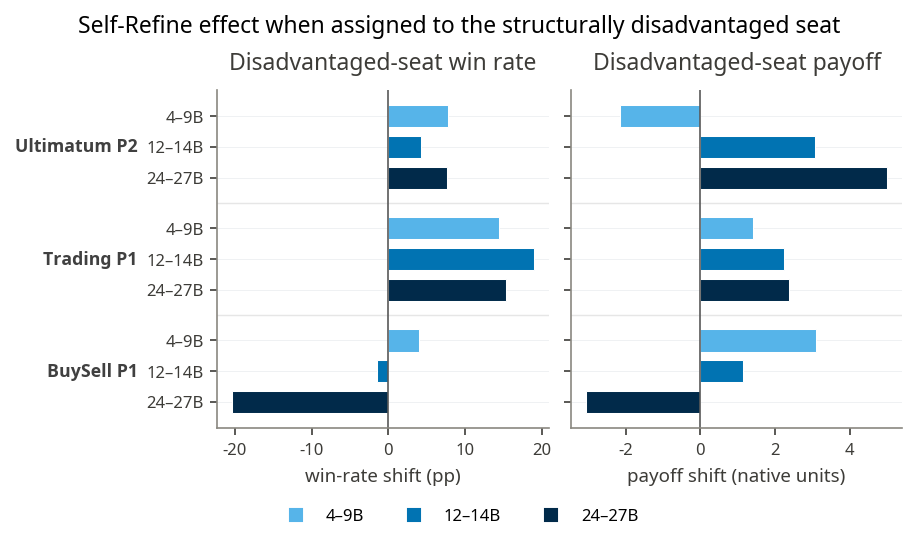

PLOT_DATA[refine_structural_disadvantaged_effects]
[{"game":"BuySell","seat":"P1","size":"medium","default_wr":0.6102,"refine_wr":0.4068,"wr_delta":-0.2034,"default_pay":11.564,"refine_pay":8.5,"pay_delta":-3.064},{"game":"BuySell","seat":"P1","size":"small","default_wr":0.1429,"refine_wr":0.1282,"wr_delta":-0.0147,"default_pay":1.548,"refine_pay":2.678,"pay_delta":1.131},{"game":"BuySell","seat":"P1","size":"very_small","default_wr":0.4211,"refine_wr":0.4615,"wr_delta":0.0405,"default_pay":6.446,"refine_pay":9.538,"pay_delta":3.092},{"game":"Trading","seat":"P1","size":"medium","default_wr":0.0741,"refine_wr":0.2281,"wr_delta":0.154,"default_pay":-4.638,"refine_pay":-2.266,"pay_delta":2.372},{"game":"Trading","seat":"P1","size":"small","default_wr":0.1803,"refine_wr":0.3704,"wr_delta":0.19,"default_pay":-3.571,"refine_pay":-1.337,"pay_delta":2.234},{"game":"Trading","seat":"P1","size":"very_small","default_wr":0.1957,"refine_wr":0.3404,"wr_delta":0.1448,"default_pay":-3.349,"refine_pa

In [80]:
from matplotlib.lines import Line2D

# Visual version of the disadvantaged-seat table. The left panel shows the win-rate
# shift in percentage points; the right panel shows the payoff shift in native units.
# Rows are grouped by structurally disadvantaged seat, with the tier labels shown
# separately to avoid cramped two-line tick labels.
GROUP_ORDER = [("Ultimatum", "P2"), ("Trading", "P1"), ("BuySell", "P1")]
GROUP_GAP = 0.65

plot_rows = []
y_pos = 0.0
group_centers = []
group_breaks = []
for game, seat in GROUP_ORDER:
    group_ys = []
    for size in SIZES:
        row = main_disadv[
            (main_disadv["game"] == game)
            & (main_disadv["seat"] == seat)
            & (main_disadv["size"] == size)
        ]
        if row.empty:
            continue
        r = row.iloc[0].to_dict()
        r["y"] = y_pos
        r["tier_label"] = SIZE_LABEL[size]
        plot_rows.append(r)
        group_ys.append(y_pos)
        y_pos += 1.0
    if group_ys:
        group_centers.append((game, seat, float(np.mean(group_ys))))
        group_breaks.append(group_ys[-1] + (1.0 + GROUP_GAP) / 2)
        y_pos += GROUP_GAP

plot_df = pd.DataFrame(plot_rows)
fig, (ax_wr, ax_pay) = plt.subplots(1, 2, figsize=(FULL_WIDTH, 3.5), sharey=True)
y = plot_df["y"].values
colors = [SIZE_COLORS[s] for s in plot_df["size"]]
ax_wr.barh(y, plot_df["wr_delta"] * 100, height=0.72, color=colors,
           edgecolor="white", linewidth=0.5)
ax_pay.barh(y, plot_df["pay_delta"], height=0.72, color=colors,
            edgecolor="white", linewidth=0.5)

for ax in (ax_wr, ax_pay):
    ax.axvline(0, color="0.35", lw=0.8)
    ax.set_yticks(y, plot_df["tier_label"])
    ax.tick_params(axis="y", pad=3)
    for sep in group_breaks[:-1]:
        ax.axhline(sep, color="0.90", lw=0.7, zorder=0)
ax_wr.invert_yaxis()

for game, seat, center in group_centers:
    ax_wr.text(-0.24, center, f"{game} {seat}", transform=ax_wr.get_yaxis_transform(),
               ha="right", va="center", fontsize=8.5, fontweight="bold",
               color="0.25", clip_on=False)

ax_wr.set_xlabel("win-rate shift (pp)")
ax_pay.set_xlabel("payoff shift (native units)")
ax_wr.set_title("Disadvantaged-seat win rate")
ax_pay.set_title("Disadvantaged-seat payoff")
legend_handles = [Line2D([], [], marker="s", ls="", color=SIZE_COLORS[s], label=SIZE_LABEL[s])
                  for s in SIZES]
fig.legend(handles=legend_handles, loc="outside lower center", ncols=3, frameon=False)
fig.suptitle("Self-Refine effect when assigned to the structurally disadvantaged seat")
save_plot(fig, "refine_structural_disadvantaged_effects"); plt.show()

print_plot_frame(
    "refine_structural_disadvantaged_effects", plot_df,
    columns=["game", "seat", "size", "default_wr", "refine_wr", "wr_delta",
             "default_pay", "refine_pay", "pay_delta"],
    sort_by=["game", "seat", "size"],
    round_cols={"default_wr": 4, "refine_wr": 4, "wr_delta": 4,
                "default_pay": 3, "refine_pay": 3, "pay_delta": 3})

The main pattern is asymmetric. When refinement is assigned to the structurally disadvantaged seat — P1 in Trading and BuySell, P2 in Ultimatum — that seat improves in 7 of 9 game×tier cells, with an average win-rate shift of +5.7 percentage points and an average payoff shift of +1.5 native units. The already-advantaged seats improve in only 2–3 of 9 cells, averaging −2.8 points and −1.3 payoff units. Trading P1 is the cleanest case: Self-Refine raises both win rate and payoff in all three tiers. The clearest exception is medium-tier BuySell P1, where the default seller was already winning most of its games and refinement reduces both win rate and seller surplus.

### Matched default-vs-refine scatter

One point per `game × seat × tier`, pooled across the three model families (no per-model breakdown). The seat's `DD` outcome is on the x-axis and the matched refined outcome on the y-axis, so points above the diagonal are gains from refinement and points below are losses. Colour marks whether the seat is structurally disadvantaged (P1 in Trading/BuySell, P2 in Ultimatum); the marker marks the tier; a dark ring marks cells whose 95% bootstrap CI on the delta excludes zero. The payoff panel uses each game's payoff span so the three games sit on the same 0–1 scale.

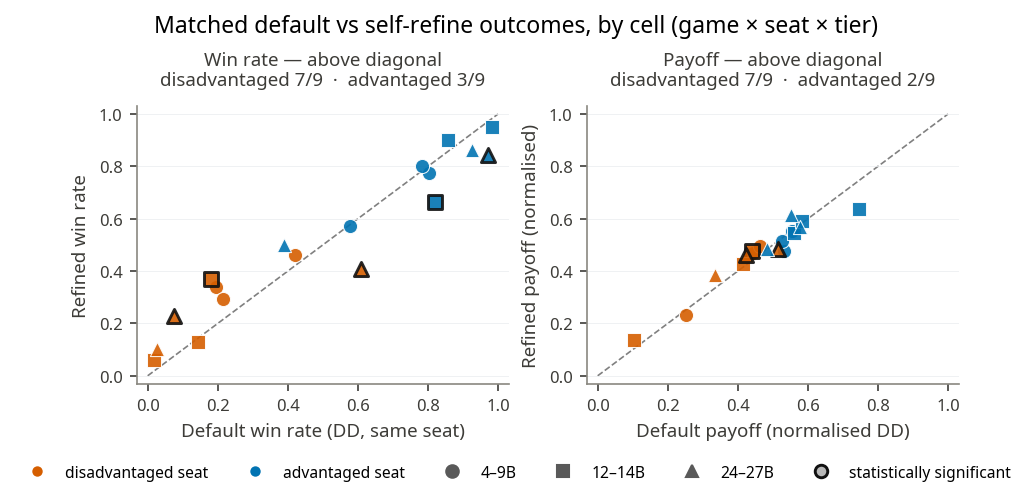

PLOT_DATA[default_vs_refine_scatter_cells]
[{"game":"BuySell","seat":"P2","size":"medium","disadvantaged":false,"default_wr":0.3898,"refined_wr":0.5,"wr_delta":0.1102,"wr_ci_excl0":false,"default_pay_norm":0.4844,"refined_pay_norm":0.4837,"pay_delta":-0.0668,"pay_ci_excl0":false},{"game":"BuySell","seat":"P2","size":"small","disadvantaged":false,"default_wr":0.8571,"refined_wr":0.9024,"wr_delta":0.0453,"wr_ci_excl0":false,"default_pay_norm":0.5821,"refined_pay_norm":0.591,"pay_delta":0.888,"pay_ci_excl0":false},{"game":"BuySell","seat":"P2","size":"very_small","disadvantaged":false,"default_wr":0.5789,"refined_wr":0.5714,"wr_delta":-0.0075,"wr_ci_excl0":false,"default_pay_norm":0.5263,"refined_pay_norm":0.5146,"pay_delta":-1.1681,"pay_ci_excl0":false},{"game":"Trading","seat":"P2","size":"medium","disadvantaged":false,"default_wr":0.9259,"refined_wr":0.8636,"wr_delta":-0.0623,"wr_ci_excl0":false,"default_pay_norm":0.5773,"refined_pay_norm":0.57,"pay_delta":-0.435,"pay_ci_excl0":false},

In [81]:
from matplotlib.lines import Line2D

# Cell-level matched scatter: one point per game x seat x tier, pooled across the
# three model families (no per-model breakdown). Default outcome on x, refined on
# y, so points above the diagonal mean refinement helped that cell. Colour marks
# whether the seat is structurally disadvantaged (P1 in Trading/BuySell, P2 in
# Ultimatum); the marker marks the tier; a dark ring marks cells whose 95%
# bootstrap CI on the delta excludes zero (per panel). Built from DISADV_SUMMARY.
PAYOFF_BOUNDS = {"Trading": (-30, 30), "Ultimatum": (0, 100), "BuySell": (-40, 60)}
DISADV_COLORS = {True: "#d55e00", False: "#0173b2"}
DISADV_LABEL = {True: "disadvantaged seat", False: "advantaged seat"}
TIER_MARKER = {"very_small": "o", "small": "s", "medium": "^"}
SIG_EDGE = "#111111"


def norm_payoff(game, payoff):
    lo, hi = PAYOFF_BOUNDS[game]
    return (payoff - lo) / (hi - lo)


cell_rows = []
for _, r in DISADV_SUMMARY.iterrows():
    if pd.isna(r["default_wr"]) or pd.isna(r["refine_wr"]):
        continue
    cell_rows.append(dict(
        game=r["game"], seat=r["seat"], size=r["size"],
        disadvantaged=bool(r["structural_disadvantaged"]),
        default_wr=r["default_wr"], refined_wr=r["refine_wr"],
        default_pay_norm=norm_payoff(r["game"], r["default_pay"]),
        refined_pay_norm=norm_payoff(r["game"], r["refine_pay"]),
        wr_delta=r["wr_delta"], pay_delta=r["pay_delta"],
        wr_ci_excl0=bool(r["wr_ci_excl0"]), pay_ci_excl0=bool(r["pay_ci_excl0"])))
CELL_CMP = pd.DataFrame(cell_rows)

fig, (ax_wr, ax_pay) = plt.subplots(1, 2, figsize=(FULL_WIDTH, 3.2))
for ax in (ax_wr, ax_pay):
    ax.plot([0, 1], [0, 1], ls="--", color="0.5", lw=0.8, zorder=0)
    ax.set_xlim(-0.03, 1.03); ax.set_ylim(-0.03, 1.03)
for _, r in CELL_CMP.iterrows():
    color = DISADV_COLORS[r.disadvantaged]; marker = TIER_MARKER[r["size"]]
    wr_edge, wr_lw = (SIG_EDGE, 1.4) if r.wr_ci_excl0 else ("white", 0.5)
    pay_edge, pay_lw = (SIG_EDGE, 1.4) if r.pay_ci_excl0 else ("white", 0.5)
    ax_wr.scatter(r.default_wr, r.refined_wr, s=46, marker=marker,
                  facecolors=color, edgecolors=wr_edge, linewidth=wr_lw, alpha=0.9, zorder=2)
    ax_pay.scatter(r.default_pay_norm, r.refined_pay_norm, s=46, marker=marker,
                   facecolors=color, edgecolors=pay_edge, linewidth=pay_lw, alpha=0.9, zorder=2)

dis = CELL_CMP[CELL_CMP.disadvantaged]
adv = CELL_CMP[~CELL_CMP.disadvantaged]
wr_dis = int((dis.wr_delta > 0).sum()); pay_dis = int((dis.pay_delta > 0).sum())
wr_adv = int((adv.wr_delta > 0).sum()); pay_adv = int((adv.pay_delta > 0).sum())
ax_wr.set_xlabel("Default win rate (DD, same seat)")
ax_wr.set_ylabel("Refined win rate")
ax_wr.set_title(f"Win rate — above diagonal\ndisadvantaged {wr_dis}/{len(dis)}  ·  advantaged {wr_adv}/{len(adv)}",
                fontsize=9)
ax_pay.set_xlabel("Default payoff (normalised DD)")
ax_pay.set_ylabel("Refined payoff (normalised)")
ax_pay.set_title(f"Payoff — above diagonal\ndisadvantaged {pay_dis}/{len(dis)}  ·  advantaged {pay_adv}/{len(adv)}",
                 fontsize=9)

leg_disadv = [Line2D([], [], marker="o", ls="", markerfacecolor=DISADV_COLORS[k],
                     markeredgecolor="white", color=DISADV_COLORS[k], label=DISADV_LABEL[k])
              for k in (True, False)]
leg_tier = [Line2D([], [], marker=TIER_MARKER[s], ls="", color="0.35", label=SIZE_LABEL[s])
            for s in SIZES]
leg_ci = [Line2D([], [], marker="o", ls="", markerfacecolor="0.72",
                 markeredgecolor=SIG_EDGE, markeredgewidth=1.4, color="0.72",
                 label="statistically significant")]
fig.legend(handles=leg_disadv + leg_tier + leg_ci, loc="outside lower center", ncols=6,
           frameon=False, fontsize=7.5)
fig.suptitle("Matched default vs self-refine outcomes, by cell (game × seat × tier)")
save_plot(fig, "default_vs_refine_scatter_cells"); plt.show()

print_plot_frame(
    "default_vs_refine_scatter_cells", CELL_CMP,
    columns=["game", "seat", "size", "disadvantaged", "default_wr", "refined_wr",
             "wr_delta", "wr_ci_excl0", "default_pay_norm", "refined_pay_norm",
             "pay_delta", "pay_ci_excl0"],
    sort_by=["disadvantaged", "game", "seat", "size"],
    round_cols={"default_wr": 4, "refined_wr": 4, "wr_delta": 4,
                "default_pay_norm": 4, "refined_pay_norm": 4, "pay_delta": 4})


Read as cells, the asymmetry is visual: the structurally disadvantaged seat lands above the diagonal in 7 of 9 cells on both win rate and payoff, while the advantaged seat improves in only 2–3 of 9 and otherwise clusters on or below the line. The movement is consistent in direction across tiers rather than large in any single cell — Trading P1 sits above the diagonal at all three tiers, the clearest case.

## 3. How does refinement change the move?


Self-refine gives the same agent a chance to revise its draft before the move is
sent. To see whether those loops harden or soften the actual proposal, this cell
uses the same estimand as the team-negotiation revision plot: parse the initial
and final proposal, score each by the payoff the proposing agent would receive if
that proposal were accepted, and classify the signed change. 


Positive means the agent asks for more value (**harden**), negative means it concedes value
(**soften**), and zero means **no move**. Accept/no-proposal turns are skipped,
so the bars describe proposal turns with parseable initial and final offers.


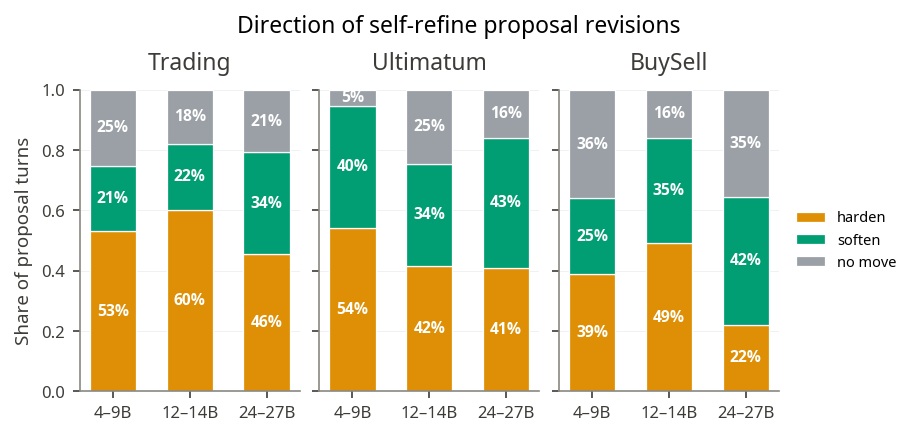

PLOT_DATA[refine_revision_direction]
[{"game":"BuySell","size":"medium","size_label":"24\u201327B","revision_direction":"harden","n":80,"total":361,"share":0.222},{"game":"BuySell","size":"medium","size_label":"24\u201327B","revision_direction":"no move","n":128,"total":361,"share":0.355},{"game":"BuySell","size":"medium","size_label":"24\u201327B","revision_direction":"soften","n":153,"total":361,"share":0.424},{"game":"BuySell","size":"small","size_label":"12\u201314B","revision_direction":"harden","n":134,"total":272,"share":0.493},{"game":"BuySell","size":"small","size_label":"12\u201314B","revision_direction":"no move","n":43,"total":272,"share":0.158},{"game":"BuySell","size":"small","size_label":"12\u201314B","revision_direction":"soften","n":95,"total":272,"share":0.349},{"game":"BuySell","size":"very_small","size_label":"4\u20139B","revision_direction":"harden","n":97,"total":250,"share":0.388},{"game":"BuySell","size":"very_small","size_label":"4\u20139B","revision_direction"

In [82]:
# Harden / soften / no-move breakdown of self-refine loops, by game and tier.
# This mirrors the team-negotiation revision figure: parse initial and final
# offers, score each by the proposer's payoff-if-accepted, then sign final - initial.
import re
SELF_REFINE_LOG_ROOT = ROOT_DIR / ".logs" / "self_refine"
SR_EXP_GAME = {
    "trading_self_refine_v1": "Trading",
    "buysell_self_refine_v1": "BuySell",
    "ultimatum_self_refine_v1": "Ultimatum",
}
SR_STRATEGY_RE = re.compile(r"_([a-z_]+)P1_([a-z_]+)P2$")
TRACE_NAME_RE = re.compile(r"refine_trace_iter_(\d+)_turn_(\d+)")


def _tag_text(text, tag):
    m = re.search(rf"<{re.escape(tag)}>(.*?)</{re.escape(tag)}>", text,
                  re.S | re.I)
    return m.group(1).strip() if m else None


def _actor_from_text(text, turn_n=None):
    raw = _tag_text(text, "my name") or ""
    m = re.search(r"Player\s+(RED|BLUE)", raw, re.I)
    if m:
        return m.group(1).upper()
    return "RED" if turn_n == 0 else "BLUE"


def parse_self_claim(text, game, turn_n=None):
    """Payoff the acting agent would get if its proposed trade were accepted."""
    trade = _tag_text(text, "newly proposed trade")
    if not trade or "NONE" in trade[:20].upper():
        return None
    actor = _actor_from_text(text, turn_n)
    other = "BLUE" if actor == "RED" else "RED"
    compact = re.sub(r"\s+", " ", trade)

    if game == "BuySell":
        price = None
        m = re.search(r"Gives\s+ZUP:\s*([-+]?\d+\.?\d*)", compact, re.I)
        if m:
            price = float(m.group(1))
        else:
            m = re.search(r":\s*([-+]?\d+\.?\d*)\s+ZUP", compact, re.I)
            if m:
                price = float(m.group(1))
        if price is None:
            return None
        return price - 40.0 if actor == "RED" else 60.0 - price

    if game == "Ultimatum":
        amounts = {name.upper(): float(amt) for name, amt in re.findall(
            r"Player\s+(RED|BLUE)\s+Gives\s+Dollars:\s*([-+]?\d+\.?\d*)",
            compact, re.I)}
        if actor not in amounts and other not in amounts:
            return None
        own_gives = amounts.get(actor, 0.0)
        other_gives = amounts.get(other, 0.0)
        initial = 100.0 if actor == "RED" else 0.0
        return initial - own_gives + other_gives

    if game == "Trading":
        def given_by(player):
            m = re.search(rf"Player\s+{player}\s+Gives(.*?)(?:\|\s*Player\s+(?:RED|BLUE)|$)",
                          compact, re.I)
            if not m:
                return 0.0
            return sum(float(n) for n in re.findall(r"[-+]?\d+\.?\d*", m.group(1)))
        return given_by(other) - given_by(actor)

    return None


def _self_refine_trace_meta(trace_path):
    parts = trace_path.relative_to(SELF_REFINE_LOG_ROOT).parts
    if len(parts) < 5:
        return None
    game = SR_EXP_GAME.get(parts[0])
    size = parts[1]
    if game is None or size not in SIZES:
        return None
    p1_strategy = p2_strategy = None
    for piece in reversed(parts[2:-1]):
        m = SR_STRATEGY_RE.search(piece)
        if m:
            p1_strategy, p2_strategy = m.group(1), m.group(2)
            break
    if p1_strategy is None:
        return None
    tm = TRACE_NAME_RE.search(trace_path.stem)
    if not tm:
        return None
    turn_n = int(tm.group(2))
    if (turn_n == 0 and p1_strategy != "self_refine") or (turn_n == 1 and p2_strategy != "self_refine"):
        return None
    return {"game": game, "size": size, "turn_n": turn_n}


rev_rows = []
for trace_path in sorted(SELF_REFINE_LOG_ROOT.rglob("refine_trace_iter_*.json")):
    meta = _self_refine_trace_meta(trace_path)
    if meta is None:
        continue
    try:
        with open(trace_path) as f:
            trace = json.load(f)
    except Exception:
        continue
    ca = parse_self_claim(trace.get("initial_draft", ""), meta["game"], meta["turn_n"])
    cb = parse_self_claim(trace.get("final", ""), meta["game"], meta["turn_n"])
    if ca is None or cb is None:
        continue
    delta = cb - ca
    rev_rows.append({**meta, "initial_claim": ca, "final_claim": cb, "delta": delta,
                     "revision_direction": "harden" if delta > 0 else
                                           "soften" if delta < 0 else "no move"})

REV = pd.DataFrame(rev_rows)
REV_ORDER = ["harden", "soften", "no move"]
REVCOL = {"harden": "#de8f05", "soften": "#029e73", "no move": "#9aa0a6"}
if REV.empty:
    print("[skip] no parseable self-refine proposal traces")
else:
    counts = (REV.groupby(["game", "size", "revision_direction"], observed=True)
              .size().rename("n").reset_index())
    totals = (REV.groupby(["game", "size"], observed=True)
              .size().rename("total").reset_index())
    games_present = [g for g in GAME_ORDER if g in set(REV["game"])]
    grid = pd.MultiIndex.from_product(
        [games_present, SIZES, REV_ORDER],
        names=["game", "size", "revision_direction"]
    ).to_frame(index=False)
    rev_plot = (grid
                .merge(counts, how="left")
                .merge(totals, how="left"))
    rev_plot["n"] = rev_plot["n"].fillna(0).astype(int)
    rev_plot["total"] = rev_plot["total"].fillna(0).astype(int)
    rev_plot["share"] = np.where(
        rev_plot["total"] > 0,
        rev_plot["n"] / rev_plot["total"],
        np.nan,
    )
    rev_plot["size_label"] = rev_plot["size"].map(SIZE_LABEL)

    fig, axes = plt.subplots(1, len(games_present), figsize=(FULL_WIDTH, 2.8),
                             sharey=True, squeeze=False)
    axes = axes[0]
    x = np.arange(len(SIZES))
    for ax, game in zip(axes, games_present):
        sub = rev_plot[rev_plot["game"] == game]
        bottom = np.zeros(len(SIZES))
        for cat in REV_ORDER:
            vals = (sub[sub["revision_direction"] == cat]
                    .set_index("size").reindex(SIZES)["share"]
                    .fillna(0).values)
            ax.bar(x, vals, 0.6, bottom=bottom, color=REVCOL[cat], label=cat,
                   edgecolor="white", linewidth=0.6)
            for xi, (v, b) in enumerate(zip(vals, bottom)):
                if v > 0.04:
                    ax.text(xi, b + v / 2, f"{v:.0%}", ha="center", va="center",
                            fontsize=7.5, color="white", fontweight="bold")
            bottom += vals
        ax.set_xticks(x, [SIZE_LABEL[s] for s in SIZES])
        ax.set_ylim(0, 1)
        ax.set_title(game)
    axes[0].set_ylabel("Share of proposal turns")
    axes[-1].legend(fontsize=7, loc="center left", bbox_to_anchor=(1.02, 0.5),
                    frameon=False)
    fig.suptitle("Direction of self-refine proposal revisions")
    save_plot(fig, "refine_revision_direction"); plt.show()
    print_plot_frame(
        "refine_revision_direction", rev_plot,
        columns=["game", "size", "size_label", "revision_direction", "n", "total", "share"],
        sort_by=["game", "size", "revision_direction"],
        round_cols={"share": 3})


When a loop actually changes the offer, it hardens (asks for more) more often than it softens, most strongly in Trading (harden ≈ .46–.60, peaking at the small tier) and at smaller sizes. The exceptions tilt the other way: medium BuySell and Ultimatum soften slightly (soften ≈ .42–.43). A sizeable share of loops make no move at all (e.g. BuySell medium .36), so refinement often leaves the offer untouched. This hardening tendency is the behavioural channel behind the weak-seat gains, examined next.

### Mechanism: does refinement harden weak seats?

The outcome table suggests Self-Refine is most useful when the focal agent starts
from a weak bargaining position. This trace-level block checks whether that comes
from the refinement loop making the agent ask for more value before committing
its move. Positive ambition deltas mean the final move gives the acting agent
more payoff-if-accepted than its initial draft.


PLOT_DATA[self_refine_mechanism_direction]
[{"game_display":"BuySell","active_seat":"P1","structural_disadvantaged":true,"direction":"more_generous","n":191,"total":795,"share":0.2403},{"game_display":"BuySell","active_seat":"P1","structural_disadvantaged":true,"direction":"more_selfish","n":238,"total":795,"share":0.2994},{"game_display":"BuySell","active_seat":"P1","structural_disadvantaged":true,"direction":"no_proposal","n":137,"total":795,"share":0.1723},{"game_display":"BuySell","active_seat":"P1","structural_disadvantaged":true,"direction":"unchanged","n":229,"total":795,"share":0.2881},{"game_display":"BuySell","active_seat":"P2","structural_disadvantaged":false,"direction":"more_generous","n":141,"total":619,"share":0.2278},{"game_display":"BuySell","active_seat":"P2","structural_disadvantaged":false,"direction":"more_selfish","n":101,"total":619,"share":0.1632},{"game_display":"BuySell","active_seat":"P2","structural_disadvantaged":false,"direction":"no_proposal","n":267,"tot

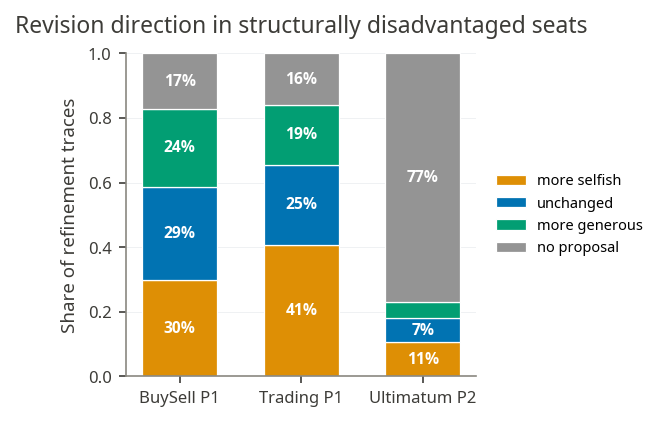

In [83]:
# Trace-level mechanism analysis. Use the richer trace summary for action/no-proposal
# accounting and align the active seat with the structural role asymmetries.
TRACE_MECH = TSUM_ALL.copy()
if TRACE_MECH.empty:
    print("[skip] no self-refine trace summary rows")
else:
    TRACE_MECH["game_display"] = TRACE_MECH["game"].map(game_disp).fillna(TRACE_MECH["game"])
    TRACE_MECH["active_seat"] = np.where((TRACE_MECH["turn_n"] % 2) == 0, "P1", "P2")
    TRACE_MECH["active_strategy"] = np.where(
        TRACE_MECH["active_seat"] == "P1",
        TRACE_MECH["p1_strategy"],
        TRACE_MECH["p2_strategy"],
    )
    TRACE_MECH = TRACE_MECH[TRACE_MECH["active_strategy"] == "self_refine"].copy()
    TRACE_MECH["structural_disadvantaged"] = [
        (g, seat) in STRUCTURAL_DISADVANTAGED
        for g, seat in zip(TRACE_MECH["game_display"], TRACE_MECH["active_seat"])
    ]
    TRACE_MECH["action_changed_num"] = TRACE_MECH["action_changed"].map({True: 1.0, False: 0.0})

    mech_counts = (TRACE_MECH.groupby(["game_display", "active_seat", "structural_disadvantaged", "direction"], observed=True)
                   .size().rename("n").reset_index())
    mech_totals = (TRACE_MECH.groupby(["game_display", "active_seat", "structural_disadvantaged"], observed=True)
                   .size().rename("total").reset_index())
    mech_grid = pd.MultiIndex.from_product(
        [GAME_ORDER, ["P1", "P2"], [False, True], DIRECTION_ORDER],
        names=["game_display", "active_seat", "structural_disadvantaged", "direction"],
    ).to_frame(index=False)
    mech_plot = mech_grid.merge(mech_counts, how="left").merge(mech_totals, how="left")
    mech_plot["n"] = mech_plot["n"].fillna(0).astype(int)
    mech_plot["total"] = mech_plot["total"].fillna(0).astype(int)
    mech_plot["share"] = np.where(mech_plot["total"] > 0, mech_plot["n"] / mech_plot["total"], np.nan)
    mech_plot = mech_plot[mech_plot["total"] > 0].copy()

    mech_delta = (TRACE_MECH.groupby(["game_display", "active_seat", "structural_disadvantaged"], observed=True)
                  .agg(n=("ambition_delta", "size"),
                       mean_ambition_delta=("ambition_delta", "mean"),
                       median_ambition_delta=("ambition_delta", "median"),
                       action_changed_rate=("action_changed_num", "mean"))
                  .reset_index())

    print_plot_frame(
        "self_refine_mechanism_direction", mech_plot,
        columns=["game_display", "active_seat", "structural_disadvantaged",
                 "direction", "n", "total", "share"],
        sort_by=["game_display", "active_seat", "direction"],
        round_cols={"share": 4})
    print_plot_frame(
        "self_refine_mechanism_ambition_delta", mech_delta,
        columns=["game_display", "active_seat", "structural_disadvantaged", "n",
                 "mean_ambition_delta", "median_ambition_delta", "action_changed_rate"],
        sort_by=["game_display", "active_seat"],
        round_cols={"mean_ambition_delta": 3, "median_ambition_delta": 3,
                    "action_changed_rate": 4})

    focus = mech_plot[mech_plot["structural_disadvantaged"]].copy()
    focus["panel"] = focus["game_display"] + " " + focus["active_seat"]
    panels = [f"{g} {seat}" for g, seat in sorted(STRUCTURAL_DISADVANTAGED)]
    focus["panel"] = pd.Categorical(focus["panel"], categories=panels, ordered=True)
    focus = focus.sort_values(["panel", "direction"])

    fig, ax = plt.subplots(figsize=(HALF_WIDTH + 1.0, 2.7))
    x = np.arange(len(panels))
    bottom = np.zeros(len(panels))
    for direction in DIRECTION_ORDER:
        vals = (focus[focus["direction"] == direction]
                .set_index("panel").reindex(panels)["share"].fillna(0).values)
        ax.bar(x, vals, 0.62, bottom=bottom, label=DIRECTION_LABEL[direction],
               color=DIRECTION_COLORS[direction], edgecolor="white", linewidth=0.6)
        for xi, (v, b) in enumerate(zip(vals, bottom)):
            if v > 0.06:
                ax.text(xi, b + v / 2, f"{v:.0%}", ha="center", va="center",
                        color="white", fontsize=7.5, fontweight="bold")
        bottom += vals
    ax.set_xticks(x, panels)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Share of refinement traces")
    ax.set_title("Revision direction in structurally disadvantaged seats")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=7)
    save_plot(fig, "refine_mechanism_disadvantaged_direction"); plt.show()


In structurally weak seats, refinement often moves the final proposal
toward the agent's own payoff: Trading P1 hardens in 40.8% of traces versus
18.6% softening, and BuySell P1 hardens in 29.9% versus 24.0% softening.
Ultimatum P2 is less diagnostic because 77.1% of traces contain no parseable
proposal change, but the mean ambition delta is still positive among all traces.


## 4. Cost

Self-Refine commits a single move but pays for five model calls: a draft plus
two critique-and-rewrite passes. To size that overhead, we count the characters
the model *generates* per move. For a default move that is just its answer; for a
self-refine move it is the draft, the two critiques, and the two rewrites summed.
Both are compared against the length of the move actually committed.

In [ ]:
import glob

# Cost proxy: characters the model GENERATES to commit one move. A default move is a
# single answer; a self-refine move adds a draft plus two critique/rewrite passes
# (5 calls), so we also sum the whole loop's text. The committed-move length is shown
# too, so the contrast is the amount of generation, not the final answer's size.
SR_LOGS = ROOT_DIR / ".logs" / "self_refine"
GAME_FROM_EXP = {"trading": "Trading", "ultimatum": "Ultimatum", "buysell": "BuySell"}


def _tier_from_path(p):
    p = p.replace(os.sep, "/")
    for s in SIZES:
        if f"/{s}/" in p:
            return s
    return None


cost_rows = []
# Default arm: length of the single committed answer, pure DD self-play.
for g in games_l:
    pat = str(SR_LOGS / f"{g}_self_refine_v1" / "**" / "game_state.json")
    for gs in glob.glob(pat, recursive=True):
        if "defaultP1_defaultP2" not in gs:
            continue
        data = json.load(open(gs))
        for st in data.get("game_state", []):
            txt = st.get("player_complete_answer")
            if txt:
                cost_rows.append(dict(game=GAME_FROM_EXP[g], size=_tier_from_path(gs),
                                      arm="default", scope="committed", n_chars=len(txt)))
# Self-refine arm: committed final length and total text generated across the loop.
for g in games_l:
    pat = str(SR_LOGS / f"{g}_self_refine_v1" / "**" / "refine_trace_*.json")
    for tp in glob.glob(pat, recursive=True):
        tr = json.load(open(tp))
        total = len(tr.get("initial_draft", ""))
        for it in tr.get("iterations", []):
            total += len(it.get("feedback", "")) + len(it.get("refined", ""))
        size = _tier_from_path(tp)
        cost_rows.append(dict(game=GAME_FROM_EXP[g], size=size, arm="self_refine",
                              scope="committed", n_chars=len(tr.get("final", ""))))
        cost_rows.append(dict(game=GAME_FROM_EXP[g], size=size, arm="self_refine",
                              scope="total_generated", n_chars=total))
COST = pd.DataFrame(cost_rows)

groups = [
    ("Default", COST[(COST.arm == "default") & (COST.scope == "committed")]),
    ("Refine final", COST[(COST.arm == "self_refine") & (COST.scope == "committed")]),
    ("Refine total", COST[(COST.arm == "self_refine") & (COST.scope == "total_generated")]),
]
labels = [g[0] for g in groups]
data = [g[1]["n_chars"].values for g in groups]
box_colors = ["#de8f05", "#56b4e9", "#0173b2"]

fig, ax = plt.subplots(figsize=(HALF_WIDTH + 1.0, 2.8))
bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=False, widths=0.55)
for patch, col in zip(bp["boxes"], box_colors):
    patch.set_facecolor(col); patch.set_alpha(0.8); patch.set_edgecolor("white")
for med in bp["medians"]:
    med.set_color("#3D3C38"); med.set_linewidth(1.3)
ax.set_ylabel("Characters per move")
med_def, med_fin, med_tot = (float(np.median(d)) for d in data)
ax.set_title(f"Self-Refine generates ~{med_tot / med_def:.0f}x the text of a default move",
             fontsize=9.5)
ax.text(0.03, 0.96,
        f"median chars: default {med_def:.0f}, refine final {med_fin:.0f}, refine total {med_tot:.0f}",
        transform=ax.transAxes, fontsize=7, va="top",
        bbox=dict(boxstyle="round", fc="white", ec="0.7", lw=0.5))
save_plot(fig, "self_refine_cost_chars"); plt.show()

summary = (COST.assign(view=COST["arm"] + "_" + COST["scope"])
           .groupby("view")["n_chars"]
           .agg(n="size", median_chars="median", mean_chars="mean")
           .reset_index())
print_plot_frame("self_refine_cost_chars", summary,
                 columns=["view", "n", "median_chars", "mean_chars"], sort_by=["view"],
                 round_cols={"median_chars": 0, "mean_chars": 0})

by_tier = (COST.groupby(["size", "arm", "scope"])["n_chars"].median()
           .reset_index().rename(columns={"n_chars": "median_chars"}))
print_plot_frame("self_refine_cost_chars_by_tier", by_tier,
                 columns=["size", "arm", "scope", "median_chars"],
                 sort_by=["arm", "scope", "size"], round_cols={"median_chars": 0})


The committed move is the same length either way (median ~790 characters), but
self-refine generates about six times as much text to produce it (median ~4,900
across its five calls). That overhead buys a gain confined to the disadvantaged
seat.

## Annex — heatmaps

For the appendix: a single scannable view of *where* refining one seat moves the
outcome. Rows are game x seat, columns are model tier. Each cell is the seat's
**refine-this-seat** value minus its **seat-matched default (DD)** baseline, so
positive (blue) = refinement helped that seat, negative (red) = it hurt.
**Bold** cells mark the structurally disadvantaged seat (P1 in Trading/BuySell,
P2 in Ultimatum); a trailing `*` marks a bootstrap 95% CI on the difference that
excludes zero. The win-rate panel is in probability units; the payoff panel is
annotated in native game units but colored on each game's payoff range so the
three games are visually comparable.


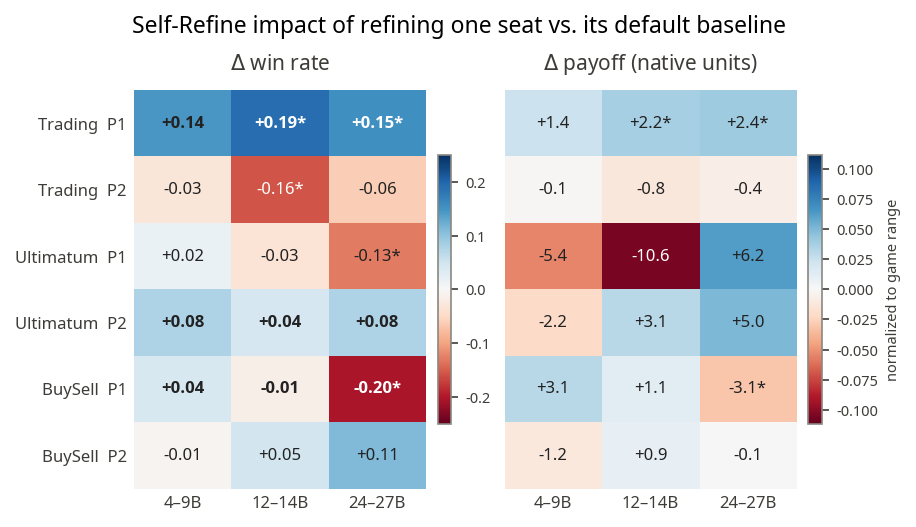

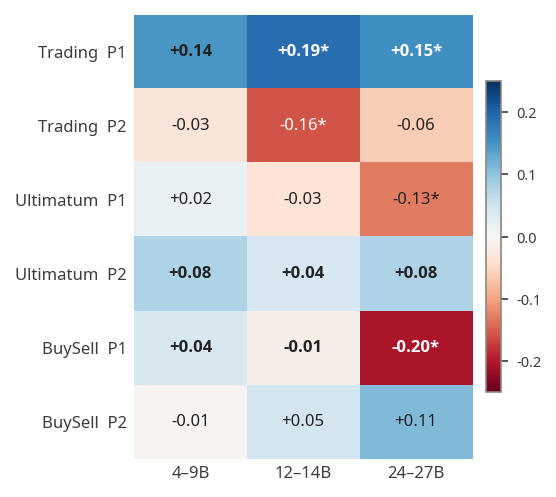

PLOT_DATA[refine_impact_heatmap]
[{"game":"Trading","seat":"P1","size":"very_small","wr_delta":0.1448,"wr_ci_excl0":false,"disadvantaged":true,"pay_delta":1.4127,"pay_ci_excl0":false},{"game":"Trading","seat":"P1","size":"small","wr_delta":0.19,"wr_ci_excl0":true,"disadvantaged":true,"pay_delta":2.2343,"pay_ci_excl0":true},{"game":"Trading","seat":"P1","size":"medium","wr_delta":0.154,"wr_ci_excl0":true,"disadvantaged":true,"pay_delta":2.3723,"pay_ci_excl0":true},{"game":"Trading","seat":"P2","size":"very_small","wr_delta":-0.0308,"wr_ci_excl0":false,"disadvantaged":false,"pay_delta":-0.0916,"pay_ci_excl0":false},{"game":"Trading","seat":"P2","size":"small","wr_delta":-0.1575,"wr_ci_excl0":true,"disadvantaged":false,"pay_delta":-0.7512,"pay_ci_excl0":false},{"game":"Trading","seat":"P2","size":"medium","wr_delta":-0.0623,"wr_ci_excl0":false,"disadvantaged":false,"pay_delta":-0.435,"pay_ci_excl0":false},{"game":"Ultimatum","seat":"P1","size":"very_small","wr_delta":0.0162,"wr_ci_excl0":

In [84]:
# Annex impact heatmaps: refine-one-seat minus seat-matched DD baseline.
# Win-rate delta (probability units) and payoff delta (native units, colored on
# each game's payoff range). Bold = structurally disadvantaged seat (P1 in
# Trading/BuySell, P2 in Ultimatum); trailing * = bootstrap 95% CI excludes zero.
PAYOFF_BOUNDS = {"Trading": (-30, 30), "Ultimatum": (0, 100), "BuySell": (-40, 60)}

_rows = [(g, s) for g in GAME_ORDER for s in (1, 2)]
_row_labels = [f"{g}  P{s}" for (g, s) in _rows]
_col_labels = [SIZE_LABEL[s] for s in SIZES]


def _winprob_vec(df, seat, setting):
    """Ties-excluded 1/0 win vector for a seat under a setting (for the CI)."""
    sub = df[df["cond"] == _SEAT_COND[(seat, setting)]]
    decisive = sub[(sub["win_1"] == 1) | (sub["win_2"] == 1)]
    col = "win_1" if seat == 1 else "win_2"
    return decisive[col].values.astype(float)


wr_delta = np.full((len(_rows), len(SIZES)), np.nan)
wr_star = np.zeros_like(wr_delta, dtype=bool)
wr_disadv = np.zeros_like(wr_delta, dtype=bool)
pay_delta = np.full_like(wr_delta, np.nan)   # native units (annotation)
pay_norm = np.full_like(wr_delta, np.nan)    # normalized to game range (color)
pay_star = np.zeros_like(wr_delta, dtype=bool)
heat_rows = []

for i, (g, seat) in enumerate(_rows):
    lo_b, hi_b = PAYOFF_BOUNDS[g]
    for j, sz in enumerate(SIZES):
        df = OUT[sz][g]
        if df is None or not len(df):
            continue
        base_wr, _, base_n = seat_winrate(df, seat, "default")
        ref_wr, _, _ = seat_winrate(df, seat, "refine")
        if not np.isnan(base_wr) and not np.isnan(ref_wr):
            wr_delta[i, j] = ref_wr - base_wr
            wr_disadv[i, j] = (g, f"P{seat}") in STRUCTURAL_DISADVANTAGED
            clo, chi = _diff_ci(_winprob_vec(df, seat, "refine"),
                                _winprob_vec(df, seat, "default"))
            wr_star[i, j] = (not np.isnan(clo)) and (clo > 0 or chi < 0)
        base_p, ref_p = seat_payoff(df, seat, "default"), seat_payoff(df, seat, "refine")
        if len(base_p) and len(ref_p):
            d = ref_p.mean() - base_p.mean()
            pay_delta[i, j] = d
            pay_norm[i, j] = d / (hi_b - lo_b)
            plo, phi = _diff_ci(ref_p, base_p)
            pay_star[i, j] = (not np.isnan(plo)) and (plo > 0 or phi < 0)
        heat_rows.append(dict(game=g, seat=f"P{seat}", size=sz,
                              wr_delta=wr_delta[i, j], wr_ci_excl0=bool(wr_star[i, j]),
                              disadvantaged=bool(wr_disadv[i, j]),
                              pay_delta=pay_delta[i, j], pay_ci_excl0=bool(pay_star[i, j])))


def _draw_heat(ax, annot, color, star, vmax, fmt, title, disadv=None):
    cm = plt.get_cmap("RdBu").copy(); cm.set_bad("#f0f0f0")
    im = ax.imshow(np.ma.masked_invalid(color), cmap=cm, vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(_col_labels)), _col_labels)
    ax.set_yticks(range(len(_row_labels)), _row_labels)
    ax.grid(False); ax.tick_params(length=0)
    for sp in ax.spines.values():
        sp.set_visible(False)
    for i in range(annot.shape[0]):
        for j in range(annot.shape[1]):
            if np.isnan(annot[i, j]):
                continue
            txt = fmt.format(annot[i, j]) + ("*" if star[i, j] else "")
            tc = "white" if abs(color[i, j]) > 0.6 * vmax else "#222222"
            fw = "bold" if (disadv is not None and disadv[i, j]) else "normal"
            ax.text(j, i, txt, ha="center", va="center", color=tc, fontsize=8, fontweight=fw)
    ax.set_title(title, fontsize=10)
    return im


fig, axes = plt.subplots(1, 2, figsize=(FULL_WIDTH, 3.4))
im0 = _draw_heat(axes[0], wr_delta, wr_delta, wr_star, 0.25, "{:+.2f}",
                 r"$\Delta$ win rate", disadv=wr_disadv)
vmax_pay = float(np.nanmax(np.abs(pay_norm))) * 1.05
im1 = _draw_heat(axes[1], pay_delta, pay_norm, pay_star, vmax_pay, "{:+.1f}",
                 r"$\Delta$ payoff (native units)")
axes[1].set_yticklabels([])
cb0 = fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04); cb0.ax.tick_params(labelsize=7)
cb1 = fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
cb1.set_label("normalized to game range", fontsize=7); cb1.ax.tick_params(labelsize=7)
fig.suptitle("Self-Refine impact of refining one seat vs. its default baseline")
save_plot(fig, "refine_impact_heatmap"); plt.show()

# Standalone win-rate heatmap (unit-consistent; convenient as a single annex fig).
fig2, ax2 = plt.subplots(figsize=(HALF_WIDTH + 0.6, 3.2))
im = _draw_heat(ax2, wr_delta, wr_delta, wr_star, 0.25, "{:+.2f}", "", disadv=wr_disadv)
cb = fig2.colorbar(im, ax=ax2, fraction=0.046, pad=0.04); cb.ax.tick_params(labelsize=7)
save_plot(fig2, "refine_winrate_impact_heatmap"); plt.show()

print_plot_frame("refine_impact_heatmap", pd.DataFrame(heat_rows),
                 columns=["game", "seat", "size", "wr_delta", "wr_ci_excl0",
                          "disadvantaged", "pay_delta", "pay_ci_excl0"],
                 round_cols={"wr_delta": 4, "pay_delta": 4})


The grid reproduces the headline pattern in one view: blue (refinement helped) concentrates on the disadvantaged seats — Trading P1 at every tier (CI-excl-0 at small/medium) and Ultimatum P2 — while red (it hurt) sits on the strong seats, Trading P2 and medium BuySell P1. Bold marks the seat that is disadvantaged on default; `*` marks a bootstrap CI that excludes zero.